# Exploratory Data Analysis (EDA) for Machine Learning & Neural Networks
## SC211 CpE Special Course: Introduction to Neural Networks

**Learning Outcomes**

After working through this notebook you should be able to:

(1) diagnose data quality problems,

(2) build a leakage-resistant preprocessing pipeline,

(3) explain *why* scaling affects optimization, and


(4) design domain-informed engineered features and justify them.



> 💡 **Key Idea** — Preprocessing ≠ Feature Engineering ≠ Data Cleaning.

## 0. Environment Setup

Reproducibility matters in ML engineering: same seed, same split, same result. We fix a global random
seed and print the library versions we relied on while building this notebook, so you know what to
expect if your output differs slightly.

In [16]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    RobustScaler,
    PowerTransformer,
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import sklearn
print(f"Python        : {sys.version.split()[0]}")
print(f"NumPy         : {np.__version__}")
print(f"pandas        : {pd.__version__}")
print(f"scikit-learn  : {sklearn.__version__}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Times New Roman'

Python        : 3.14.7
NumPy         : 2.5.2
pandas        : 3.0.5
scikit-learn  : 1.9.0


> **Common Mistake to avoid from the very first cell** — Notice that we set `RANDOM_STATE = 42`
> **once**, at the top, and reuse it everywhere (splits, models, augmentation). Re-seeding differently
> in different cells silently breaks reproducibility.

## Section 0 — Learning Objectives and the ML Pipeline

**Learning objectives (from the lecture):**
- Understand common data quality problems and how they manifest in real datasets
- Distinguish feature *creation*, *transformation*, *selection*, and *representation learning*
- Understand how preprocessing choices affect optimization (gradient descent behavior)
- Design leakage-resistant preprocessing and feature-engineering pipelines

**The conceptual workflow:**

```
Raw Data
    ↓
Data Inspection
    ↓
Data Cleaning
    ↓
Train / Validation / Test Split
    ↓
Preprocessing
    ↓
Feature Engineering
    ↓
Feature Selection
    ↓
Representation
    ↓
Model
    ↓
Evaluation
```

**A distinction the lecture insists on, and that this notebook keeps visually distinct throughout:**

```
Preprocessing  ≠  Feature Engineering  ≠  Data Cleaning
```

| Stage | Solves | Examples |
|---|---|---|
| **Data Cleaning** | Data-quality problems | Duplicates, wrong dtypes, invalid values |
| **Preprocessing** | Makes data *usable* by a model | Scaling, encoding, imputing, resizing |
| **Feature Engineering** | Makes data *more informative* | Ratios, interactions, domain features |

> **Think About It** — Notice that the split step happens *before* preprocessing in the diagram
> above. Section 7 (Leakage-Resistant Preprocessing) explains exactly why the order matters.

## Section 1 — Why Preprocessing Matters

Real-world features rarely live on the same scale. A feature like "number of bedrooms"
(0–10) and a feature like "house price" (10,000–1,000,000) coexist in the same dataset. Many models
(distance-based models, gradient-descent-trained models, regularized linear models) are sensitive to
this — a feature with a larger numeric range can dominate the loss purely due to scale, not because it
is more informative.

We build a small synthetic dataset with two numerical features on drastically different scales to make
this concrete.

In [17]:
n = 500
feature_a = np.random.normal(loc=5, scale=2, size=n)          # roughly 0-10
feature_b = np.random.normal(loc=55000, scale=15000, size=n)  # roughly 10,000-100,000

df_scale_demo = pd.DataFrame({"Feature_A": feature_a, "Feature_B": feature_b})
df_scale_demo.describe()

,Feature_A,Feature_B
count,500.000000,500.000000
mean,5.013676,55477.391756
std,1.962506,14669.957928
min,-1.482535,14546.700356
25%,3.599385,46070.623902
50%,5.025594,55427.973993
75%,6.273567,64768.634463
max,12.705463,94485.730973


### Mathematical formulation

**Standardization (z-score):**
$$
z = \frac{x - \mu}{\sigma}
$$

**Min-Max scaling:**
$$
x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

Standardization re-centers a feature to mean 0, standard deviation 1. Min-max scaling compresses a
feature into a fixed $[0, 1]$ range. Both remove the effect of arbitrary units, but they behave
differently in the presence of outliers (Section 5 revisits this).

In [18]:
mean_a, std_a = feature_a.mean(), feature_a.std()
mean_b, std_b = feature_b.mean(), feature_b.std()

print(f"Feature A -> mean: {mean_a:.2f}, std: {std_a:.2f}")
print(f"Feature B -> mean: {mean_b:.2f}, std: {std_b:.2f}")
print(f"\nCovariance:\n{df_scale_demo.cov()}")
print(f"\nCorrelation:\n{df_scale_demo.corr()}")

standardized = (df_scale_demo - df_scale_demo.mean()) / df_scale_demo.std()                     
'''He used the formula above to standardize the data, 
which is the z-score normalization. This method transforms the data '
to have a mean of 0 and a standard deviation of 1.
'''


minmax = (df_scale_demo - df_scale_demo.min()) / (df_scale_demo.max() - df_scale_demo.min())
'''He used the formula above to apply min-max scaling, which transforms the data to a fixed range, usually [0, 1].
Min-max scaling is a linear transformation that preserves the relationships between the original data points, it 
provides a way to scale the data without distorting the relationships between the values.

Min-max scaling is different from standardization in that it does not change the shape of the original distribution,
but it does change the scale of the data. Standardization, on the other hand, changes the shape of the distribution by centering the data 
around the mean and scaling it by the standard deviation

Scaling is a process of transforming the data to a specific range or distribution. 
It is important in machine learning because many algorithms are sensitive to the scale of the input features. 
Scaling can help improve the performance and convergence of these algorithms.'''

Feature A -> mean: 5.01, std: 1.96
Feature B -> mean: 55477.39, std: 14655.28

Covariance:
             Feature_A     Feature_B
Feature_A     3.851432 -2.178552e+03
Feature_B -2178.552368  2.152077e+08

Correlation:
           Feature_A  Feature_B
Feature_A   1.000000  -0.075671
Feature_B  -0.075671   1.000000


'He used the formula above to apply min-max scaling, which transforms the data to a fixed range, usually [0, 1].\nMin-max scaling is a linear transformation that preserves the relationships between the original data points, it \nprovides a way to scale the data without distorting the relationships between the values.\n\nMin-max scaling is different from standardization in that it does not change the shape of the original distribution,\nbut it does change the scale of the data. Standardization, on the other hand, changes the shape of the distribution by centering the data \naround the mean and scaling it by the standard deviation\n\nScaling is a process of transforming the data to a specific range or distribution. \nIt is important in machine learning because many algorithms are sensitive to the scale of the input features. \nScaling can help improve the performance and convergence of these algorithms.'

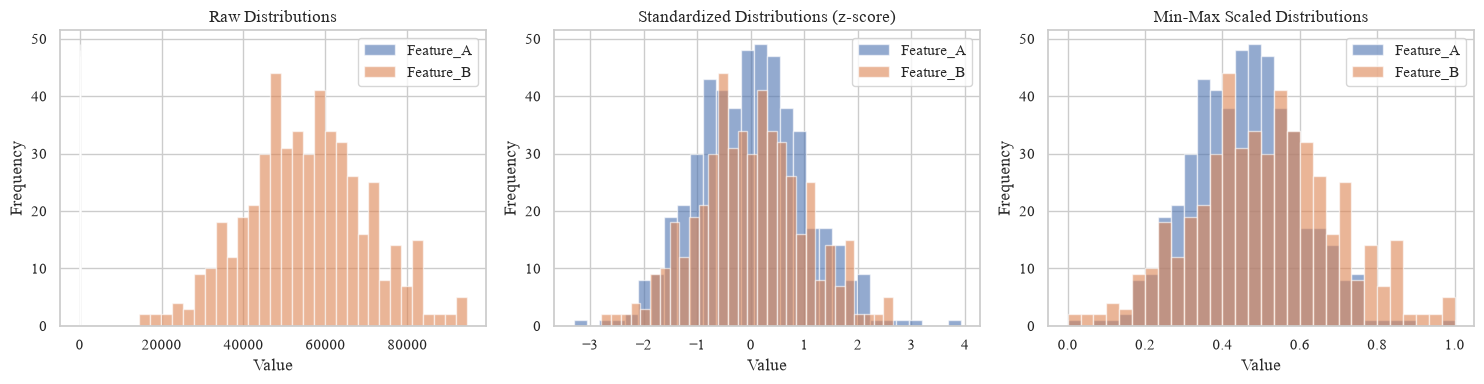

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for col in df_scale_demo.columns:
    axes[0].hist(df_scale_demo[col], bins=30, alpha=0.6, label=col)
axes[0].set_title("Raw Distributions")
axes[0].set_xlabel("Value"); axes[0].set_ylabel("Frequency"); axes[0].legend()

for col in standardized.columns:
    axes[1].hist(standardized[col], bins=30, alpha=0.6, label=col)
axes[1].set_title("Standardized Distributions (z-score)")
axes[1].set_xlabel("Value"); axes[1].set_ylabel("Frequency"); axes[1].legend()

for col in minmax.columns:
    axes[2].hist(minmax[col], bins=30, alpha=0.6, label=col)
axes[2].set_title("Min-Max Scaled Distributions")
axes[2].set_xlabel("Value"); axes[2].set_ylabel("Frequency"); axes[2].legend()

plt.tight_layout()
plt.show()

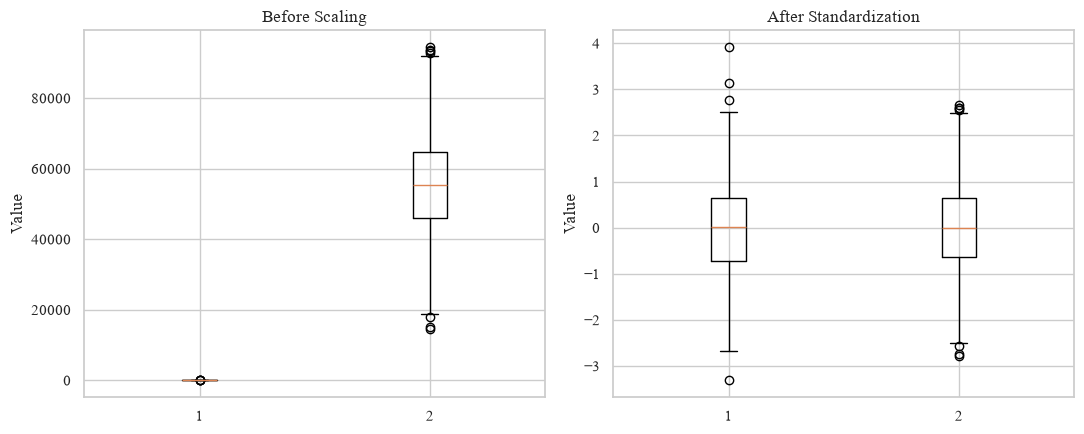

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].boxplot([df_scale_demo["Feature_A"], df_scale_demo["Feature_B"]], label=["Feature_A", "Feature_B"])
axes[0].set_title("Before Scaling"); axes[0].set_ylabel("Value")

axes[1].boxplot([standardized["Feature_A"], standardized["Feature_B"]], label=["Feature_A", "Feature_B"])
axes[1].set_title("After Standardization"); axes[1].set_ylabel("Value")
plt.tight_layout()
plt.show()

**Interpretation.** Before scaling, Feature_B's boxplot dwarfs Feature_A's — any distance-based or
gradient-based model would implicitly treat Feature_B as "more important" purely due to its numeric
range. After standardization both features occupy comparable ranges centered at 0.

**Takeaway.** Scaling does not change the *information* in a feature — the correlation between
Feature_A and Feature_B is identical before and after. It changes the *geometry* the model sees.

## Section 2 — Preprocessing and Optimization

Gradient descent moves in the direction of steepest descent on the loss surface. When
features are on very different scales, the loss surface becomes an elongated ellipse rather than a
circle — the surface is *poorly conditioned*. Gradient descent then zig-zags across the narrow
direction instead of moving efficiently toward the minimum.

We demonstrate this with a simple 2D linear regression loss surface, once with poorly scaled features
and once with standardized features.

In [21]:
np.random.seed(RANDOM_STATE)
n_pts = 200
x1_raw = np.random.normal(5, 2, n_pts)          # small-scale feature
x2_raw = np.random.normal(50000, 15000, n_pts)  # large-scale feature
true_w = np.array([3.0, 0.0002])
y_target = true_w[0] * x1_raw + true_w[1] * x2_raw + np.random.normal(0, 1, n_pts)

def mse_loss(w, X, y):
    preds = X @ w
    return np.mean((preds - y) ** 2)

def gradient_descent(X, y, w_init, lr, n_steps):
    w = w_init.copy()
    path = [w.copy()]
    for _ in range(n_steps):
        grad = (2 / len(y)) * X.T @ (X @ w - y)
        w = w - lr * grad
        path.append(w.copy())
    return np.array(path)

X_raw = np.column_stack([x1_raw, x2_raw])
X_scaled = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
# rescale target consistently so both surfaces are comparable
y_for_scaled = y_target.copy()

w_init = np.array([0.0, 0.0])
path_raw = gradient_descent(X_raw, y_target, w_init, lr=1e-8, n_steps=50)
path_scaled = gradient_descent(X_scaled, y_for_scaled, np.array([0.0, 0.0]), lr=0.1, n_steps=50)

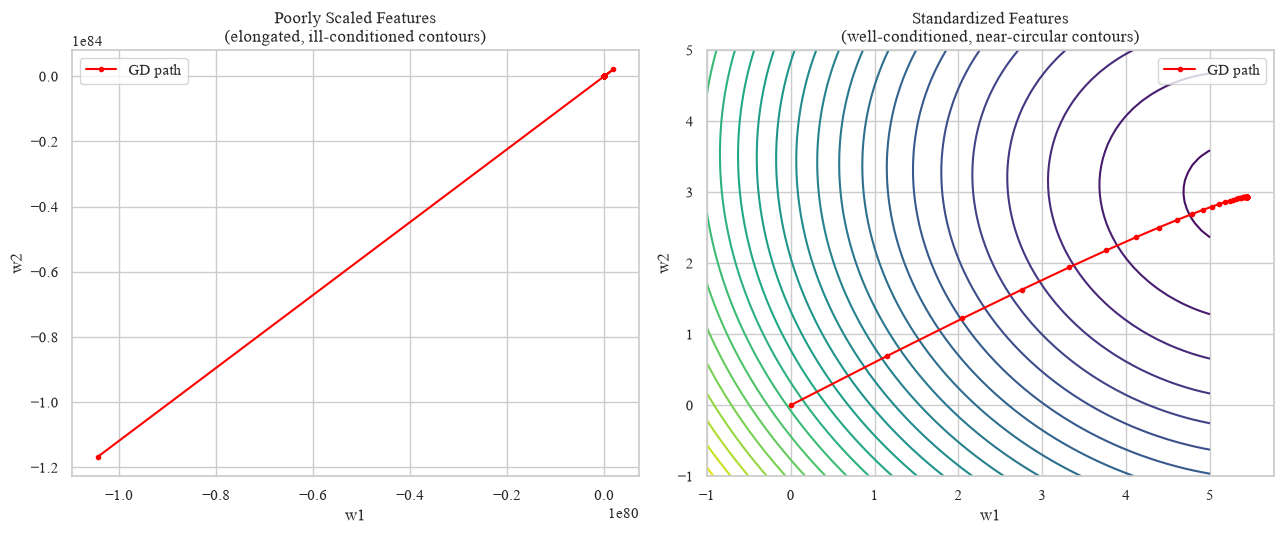

In [22]:
def loss_grid(X, y, w1_range, w2_range):
    W1, W2 = np.meshgrid(w1_range, w2_range)
    Z = np.zeros_like(W1)
    for i in range(W1.shape[0]):
        for j in range(W1.shape[1]):
            w = np.array([W1[i, j], W2[i, j]])
            Z[i, j] = mse_loss(w, X, y)
    return W1, W2, Z

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

w1r = np.linspace(-1, 5, 60)
w2r = np.linspace(-0.0005, 0.0005, 60)
W1, W2, Z = loss_grid(X_raw, y_target, w1r, w2r)
axes[0].contour(W1, W2, np.log1p(Z), levels=25, cmap="viridis")
axes[0].plot(path_raw[:, 0], path_raw[:, 1], "o-", color="red", markersize=3, label="GD path")
axes[0].set_title("Poorly Scaled Features\n(elongated, ill-conditioned contours)")
axes[0].set_xlabel("w1"); axes[0].set_ylabel("w2"); axes[0].legend()

w1r2 = np.linspace(-1, 5, 60)
w2r2 = np.linspace(-1, 5, 60)
W1s, W2s, Zs = loss_grid(X_scaled, y_for_scaled, w1r2, w2r2)
axes[1].contour(W1s, W2s, np.log1p(Zs), levels=25, cmap="viridis")
axes[1].plot(path_scaled[:, 0], path_scaled[:, 1], "o-", color="red", markersize=3, label="GD path")
axes[1].set_title("Standardized Features\n(well-conditioned, near-circular contours)")
axes[1].set_xlabel("w1"); axes[1].set_ylabel("w2"); axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation.** On the left (raw scales), the contours are extremely elongated because `x2_raw`'s
huge numeric range dominates the loss curvature — gradient descent had to use a tiny learning rate
(`1e-8`) just to avoid diverging, and still moves inefficiently. On the right (standardized features),
the contours are close to circular, and a **much larger** learning rate (`0.1`) converges smoothly and
quickly.

**Takeaway.** Poorly scaled features → elongated loss contours → gradient descent zig-zags or requires
tiny, fragile learning rates. Properly scaled features → better-conditioned optimization landscape.

## Section 3 — Data Quality

**Concept.** A dataset can look "mostly clean" at a glance and still contain problems capable of
harming model training: missing values, duplicated rows, inconsistent dtypes, outliers, noisy
measurements, and inconsistent category spellings. We deliberately corrupt a small dataset to practice
spotting these.

In [23]:
np.random.seed(RANDOM_STATE)
n = 200
messy = pd.DataFrame({
    "customer_id": range(1, n + 1),
    "age": np.random.randint(18, 70, n).astype(float),
    "income": np.random.normal(35000, 12000, n),
    "region": np.random.choice(["North", "South", "north", "SOUTH", "East", "west"], n),
    "signup_date": pd.date_range("2023-01-01", periods=n, freq="D"),
})

# inject missing values
missing_idx = np.random.choice(n, size=20, replace=False)
messy.loc[missing_idx, "income"] = np.nan
missing_idx2 = np.random.choice(n, size=10, replace=False)
messy.loc[missing_idx2, "age"] = np.nan

# inject duplicates
messy = pd.concat([messy, messy.iloc[:8]], ignore_index=True)

# inject outliers
outlier_idx = np.random.choice(messy.index, size=5, replace=False)
messy.loc[outlier_idx, "income"] = messy.loc[outlier_idx, "income"] * 15

# inconsistent dtype: age stored as string in a few rows
str_idx = np.random.choice(messy.index, size=6, replace=False)
messy["age"] = messy["age"].astype(object)
messy.loc[str_idx, "age"] = messy.loc[str_idx, "age"].astype(str)

messy.head(10)

,customer_id,age,income,region,signup_date
0,1,56.0,36524.146872,north,2023-01-01
1,2,69.0,20006.675326,East,2023-01-02
2,3,46.0,58341.387374,SOUTH,2023-01-03
3,4,32.0,33159.962510,North,2023-01-04
4,5,60.0,24116.153295,East,2023-01-05
5,6,25.0,25191.750139,East,2023-01-06
6,7,38.0,29202.527855,North,2023-01-07
7,8,56.0,28162.059819,SOUTH,2023-01-08
8,9,36.0,NaN,South,2023-01-09
9,10,40.0,50164.886369,East,2023-01-10


In [24]:
print("Shape:", messy.shape)
messy.info()
print("\nMissing values per column:\n", messy.isna().sum())
print("\nDuplicated rows:", messy.duplicated().sum())
print("\nUnique 'region' spellings:", sorted(messy["region"].unique()))

Shape: (208, 5)
<class 'pandas.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  208 non-null    int64         
 1   age          198 non-null    object        
 2   income       188 non-null    float64       
 3   region       208 non-null    str           
 4   signup_date  208 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(1), object(1), str(1)
memory usage: 8.3+ KB

Missing values per column:
 customer_id     0
age            10
income         20
region          0
signup_date     0
dtype: int64

Duplicated rows: 7

Unique 'region' spellings: ['East', 'North', 'SOUTH', 'South', 'north', 'west']


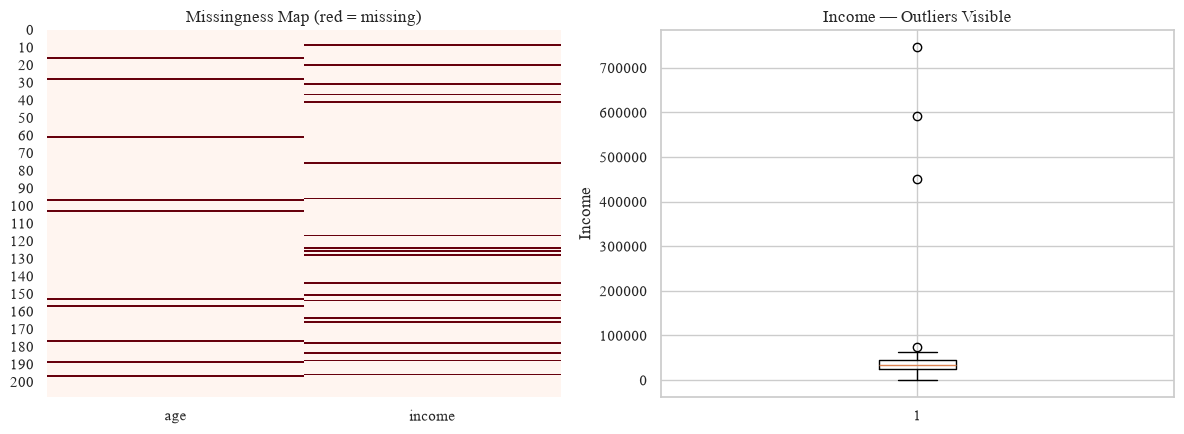

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.heatmap(messy[["age", "income"]].apply(pd.to_numeric, errors="coerce").isna(),
            cbar=False, cmap="Reds", ax=axes[0])
axes[0].set_title("Missingness Map (red = missing)")

income_numeric = pd.to_numeric(messy["income"], errors="coerce").dropna()
axes[1].boxplot(income_numeric)
axes[1].set_title("Income — Outliers Visible")
axes[1].set_ylabel("Income")
plt.tight_layout()
plt.show()

**Interpretation.** `df.info()` reveals that `age` is stored as `object` (mixed types) instead of a
numeric dtype — a silent problem that would break arithmetic operations downstream. The missingness map
shows scattered missing values in both `age` and `income`. The boxplot shows a handful of income values
far above the rest — later sections decide whether these are noise or genuine signal.

**Takeaway.** Always run `df.info()`, `df.describe()`, `df.isna().sum()`, and `df.duplicated().sum()`
*before* trusting a dataset — a dataset that "looks fine" in `.head()` can still be broken.

> **Common Mistake** — Judging data quality from `.head()` alone. Problems concentrated later in the
> dataset (or in rare categories) are invisible in the first few rows.

## Section 4 — Missing-Value Handling

We compare six approaches to missing data on the `income` column (converted to numeric first).

In [40]:
income_series = pd.to_numeric(messy["income"], errors="coerce")
print(f"Missing before: {income_series.isna().sum()} / {len(income_series)}")

# Method 1: Deletion
deleted = income_series.dropna()
print(f"Method 1 (Deletion)        -> remaining rows: {len(deleted)} "
      f"({len(income_series) - len(deleted)} rows lost)")

# Method 2: Mean imputation
mean_imputed = income_series.fillna(income_series.mean())

# Method 3: Median imputation
median_imputed = income_series.fillna(income_series.median())

# Method 4: Mode imputation (rarely appropriate for continuous data, shown for completeness)
mode_imputed = income_series.fillna(income_series.mode()[0])

# Method 5: Forward-fill / backward-fill (assumes an ordering, e.g. time)
ffill_imputed = income_series.ffill().bfill()

# Method 6: Model-based (KNN) imputation
knn_imputer = KNNImputer(n_neighbors=5)
age_numeric = pd.to_numeric(messy["age"], errors="coerce")
knn_input = pd.DataFrame({"age": age_numeric, "income": income_series})
knn_imputed = pd.DataFrame(knn_imputer.fit_transform(knn_input), columns=["age", "income"])["income"]

results = pd.DataFrame({
    "Mean Imputation": mean_imputed,
    "Median Imputation": median_imputed,
    "Mode Imputation": mode_imputed,
    "Forward/Backward Fill": ffill_imputed,
    "KNN Imputation": knn_imputed,
})
results.describe()



Missing before: 20 / 208
Method 1 (Deletion)        -> remaining rows: 188 (20 rows lost)


,Mean Imputation,Median Imputation,Mode Imputation,Forward/Backward Fill,KNN Imputation
count,208.000000,208.000000,208.000000,208.000000,208.000000
mean,43668.712252,42813.625950,41393.516394,42473.892713,44769.852972
std,69711.190754,69760.707720,70061.005113,69853.199507,71190.909730
min,446.517278,446.517278,446.517278,446.517278,446.517278
25%,26863.245988,26863.245988,22561.494611,25878.527818,26812.378362
50%,36286.852680,34775.814714,33210.911850,34443.202950,34902.197647
75%,43668.712252,41630.431165,41630.431165,42429.691796,44880.877740
max,746720.107809,746720.107809,746720.107809,746720.107809,746720.107809


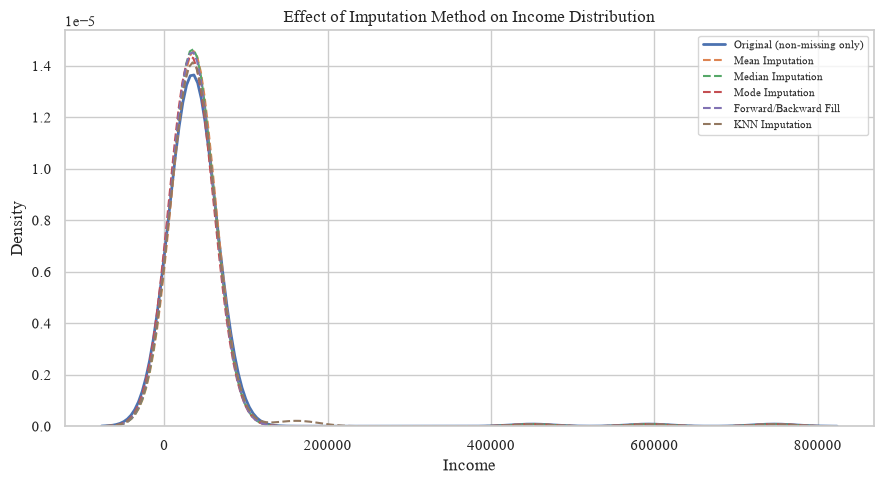

In [43]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(income_series.dropna(), label="Original (non-missing only)", linewidth=2)
for col in results.columns:
    sns.kdeplot(results[col], label=col, linestyle="--")
ax.set_title("Effect of Imputation Method on Income Distribution")
ax.set_xlabel("Income"); ax.set_ylabel("Density")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

| Method | Pros | Cons |
|---|---|---|
| **Deletion** | Simple, no assumptions injected | Loses data; biased if missingness isn't random |
| **Mean imputation** | Fast, preserves mean | Shrinks variance, distorts distribution shape |
| **Median imputation** | Robust to outliers | Still shrinks variance |
| **Mode imputation** | Works for categorical data | Rarely appropriate for continuous data |
| **Forward/backward fill** | Natural for ordered/time data | Wrong for unordered/tabular data |
| **KNN (model-based)** | Uses relationships between features | Slower; sensitive to feature scaling |

> **Data Leakage Warning** — All imputers above must be **fit on training data only** and then
> applied to validation/test data (Section 7 makes this concrete with code).

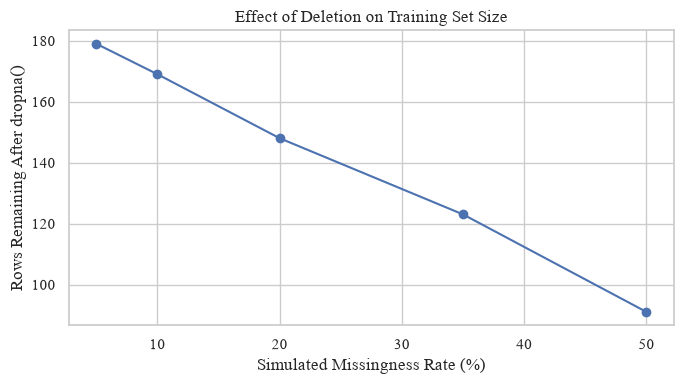

In [28]:
# Experiment: how aggressive deletion shrinks the training set
missing_rates = [0.05, 0.10, 0.20, 0.35, 0.50]
remaining_rows = []
sim_df = messy.copy()
n_total = len(sim_df)
for rate in missing_rates:
    n_missing = int(n_total * rate)
    idx = np.random.choice(sim_df.index, size=n_missing, replace=False)
    tmp = sim_df.copy()
    tmp.loc[idx, "income"] = np.nan
    remaining_rows.append(len(tmp.dropna(subset=["income"])))

plt.figure(figsize=(7, 4))
plt.plot([r * 100 for r in missing_rates], remaining_rows, "o-")
plt.title("Effect of Deletion on Training Set Size")
plt.xlabel("Simulated Missingness Rate (%)")
plt.ylabel("Rows Remaining After dropna()")
plt.tight_layout()
plt.show()

**Takeaway.** At 50% simulated missingness, deletion throws away roughly half the dataset. For small
or imbalanced datasets this can be far more damaging than a modest, well-justified imputation.

## Section 5 — Outlier Detection

**Mathematical formulation (Interquartile Range (IQR) method):**
$$
IQR = Q_3 - Q_1
$$
$$
\text{Outlier range: } [\,Q_1 - 1.5 \cdot IQR,\; Q_3 + 1.5 \cdot IQR\,]
$$

In [29]:
income_clean = income_series.dropna()

# Z-score method
z_scores = (income_clean - income_clean.mean()) / income_clean.std()
z_outliers = income_clean[np.abs(z_scores) > 3]

# IQR method
Q1, Q3 = income_clean.quantile(0.25), income_clean.quantile(0.75)
IQR = Q3 - Q1
lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
iqr_outliers = income_clean[(income_clean < lower_bound) | (income_clean > upper_bound)]

print(f"Z-score outliers (|z|>3): {len(z_outliers)}")
print(f"IQR outliers: {len(iqr_outliers)}  (bounds: [{lower_bound:.0f}, {upper_bound:.0f}])")

Z-score outliers (|z|>3): 3
IQR outliers: 4  (bounds: [-1310, 71193])


C:\Users\gonza\AppData\Local\Temp\ipykernel_20188\2414912718.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(income_clean, vert=False)


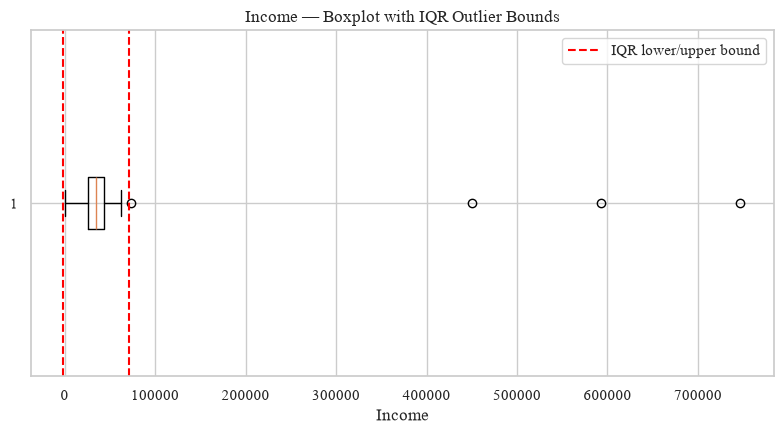

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.boxplot(income_clean, vert=False)
ax.axvline(lower_bound, color="red", linestyle="--", label="IQR lower/upper bound")
ax.axvline(upper_bound, color="red", linestyle="--")
ax.set_title("Income — Boxplot with IQR Outlier Bounds")
ax.set_xlabel("Income")
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
# Three strategies
removed = income_clean[(income_clean >= lower_bound) & (income_clean <= upper_bound)]
capped = income_clean.clip(lower=lower_bound, upper=upper_bound)
kept = income_clean.copy()

strategy_df = pd.DataFrame({
    "Original": [income_clean.mean(), income_clean.std(), len(income_clean)],
    "Removed":  [removed.mean(), removed.std(), len(removed)],
    "Capped":   [capped.mean(), capped.std(), len(capped)],
}, index=["mean", "std", "n"])
strategy_df

,Original,Removed,Capped
mean,43668.712252,34493.027252,35273.867197
std,73344.384869,12457.779046,13419.137156
n,188.000000,184.000000,188.000000


> **Common Mistake — Removing meaningful outliers.** Removing an outlier can be *harmful* if the
> outlier represents a real and important event rather than noise.
> 
> Examples:
> - **Fraud detection** — the fraudulent transaction *is* the outlier you're trying to detect
> - **Rare manufacturing defects** — the defective part is rare by definition
> - **Medical abnormalities** — an abnormal lab value may be the most clinically important row
> - **Minority-class observations** — in imbalanced classification, the minority class often looks
>   statistically like an "outlier" but is the class you care most about
>
> **Decision process:** identify → visualize → reason about *why* the value is extreme → only then
> decide whether removal, capping, or keeping is justified. Never delete outliers automatically without
> this reasoning step.

## Section 6 — Categorical Encoding

**Label / Ordinal Encoding** — appropriate only when categories have a natural order.

In [32]:
quality_levels = pd.DataFrame({"quality": np.random.choice(["Low", "Medium", "High"], 10)})

ordinal_encoder = OrdinalEncoder(categories=[["Low", "Medium", "High"]])
quality_levels["quality_encoded"] = ordinal_encoder.fit_transform(quality_levels[["quality"]])
quality_levels

,quality,quality_encoded
0,Low,0.0
1,Medium,1.0
2,Medium,1.0
3,Low,0.0
4,Low,0.0
5,Low,0.0
6,Medium,1.0
7,High,2.0
8,Medium,1.0
9,High,2.0


**One-Hot Encoding** — appropriate for *unordered* (nominal) categories, since label/ordinal encoding
would imply a false numeric ordering (e.g., "Blue" > "Red" makes no sense).

In [33]:
colors = pd.DataFrame({"color": np.random.choice(["Red", "Blue", "Green", "Yellow"], 10)})

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded = ohe.fit_transform(colors[["color"]])
ohe_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(["color"]))
pd.concat([colors, ohe_df], axis=1)

,color,color_Blue,color_Green,color_Red,color_Yellow
0,Blue,1.0,0.0,0.0,0.0
1,Blue,1.0,0.0,0.0,0.0
2,Red,0.0,0.0,1.0,0.0
3,Yellow,0.0,0.0,0.0,1.0
4,Yellow,0.0,0.0,0.0,1.0
5,Green,0.0,1.0,0.0,0.0
6,Yellow,0.0,0.0,0.0,1.0
7,Blue,1.0,0.0,0.0,0.0
8,Blue,1.0,0.0,0.0,0.0
9,Red,0.0,0.0,1.0,0.0


`handle_unknown="ignore"` matters in production: if a category unseen during training appears at
inference time, the encoder returns all-zeros for that row instead of crashing.

**The high-cardinality problem.** Consider a `zip_code` or `product_id` column with thousands of unique
values. One-hot encoding would create thousands of sparse columns — exploding dimensionality, wasting
memory, and giving the model very few examples per category to learn from. Alternatives include
grouping rare categories into an "Other" bucket, hashing, or **target encoding**.

**Target encoding (concept only)** replaces a category with the mean of the target variable for that
category (e.g., replace `city` with the average house price in that city). It's powerful for
high-cardinality features but carries a **serious leakage risk**: if computed using the *entire*
dataset (including validation/test rows), the encoding leaks target information into features the model
shouldn't see yet. Safe implementations use out-of-fold encoding computed only on training folds.

> **Data Leakage Warning** — Never compute target encoding using rows that are outside the current
> training fold.

## Section 7 — Leakage-Resistant Preprocessing

This section is extremely important.

> 💡 **The Golden Rule** — Fit preprocessing transformations **only** on training data. The
> transformation $T$ (a scaler, imputer, encoder — anything with learned statistics) must be learned
> exclusively from the training split, then **reused** (not refit) to transform validation and test
> data.

```
Experiment A — INCORRECT                 Experiment B — CORRECT
Full Dataset                              Full Dataset
     ↓                                         ↓
   Scale                              Train / Test Split
     ↓                                         ↓
Train/Test Split                    Fit scaler on training data
                                                ↓
                                   Transform validation/test with
                                      the SAME fitted scaler
```

We make the difference in evaluation *visible* with a classification experiment.

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification

X_leak, y_leak = make_classification(
    n_samples=600, n_features=10, n_informative=6, n_redundant=2,
    class_sep=0.9, random_state=RANDOM_STATE
)

# ---- Experiment A: INCORRECT — scale before splitting ----
# For demonstration of data leakage only — DO NOT USE THIS IN PRODUCTION.
scaler_wrong = StandardScaler()
X_leak_scaled_full = scaler_wrong.fit_transform(X_leak)  # fit on EVERYTHING, including future test rows
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_leak_scaled_full, y_leak, test_size=0.25, random_state=RANDOM_STATE, stratify=y_leak
)
model_a = LogisticRegression(random_state=RANDOM_STATE).fit(X_train_a, y_train_a)
acc_a = accuracy_score(y_test_a, model_a.predict(X_test_a))

# ---- Experiment B: CORRECT — split first, fit scaler on train only ----
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_leak, y_leak, test_size=0.25, random_state=RANDOM_STATE, stratify=y_leak
)
scaler_right = StandardScaler().fit(X_train_b)          # fit on TRAIN ONLY
X_train_b_scaled = scaler_right.transform(X_train_b)
X_test_b_scaled = scaler_right.transform(X_test_b)      # reuse, do not refit
model_b = LogisticRegression(random_state=RANDOM_STATE).fit(X_train_b_scaled, y_train_b)
acc_b = accuracy_score(y_test_b, model_b.predict(X_test_b_scaled))

print(f"Experiment A (scale BEFORE split, leaky)   -> test accuracy: {acc_a:.4f}")
print(f"Experiment B (scale AFTER split, correct)  -> test accuracy: {acc_b:.4f}")

Experiment A (scale BEFORE split, leaky)   -> test accuracy: 0.8333
Experiment B (scale AFTER split, correct)  -> test accuracy: 0.8333


**Interpretation.** In this particular synthetic dataset the gap may look small on a single run —
that's realistic: leakage from *scaling alone* is often subtle (it's a much bigger problem for target
encoding, feature selection, and imputation). But the mechanism is the same regardless of magnitude:
Experiment A's scaler statistics ($\mu$, $\sigma$) were computed using information from rows the model
would later be "tested" on — an information leak from test into train. As models and preprocessing get
more complex (e.g., feature selection using the full dataset, or target encoding), this same mistake
produces **optimistic, misleading evaluation** that will not hold up on truly unseen data in production.

**Takeaway.** Preprocessing the entire dataset before splitting lets statistics computed from the test
set influence what the model learns — the reported test performance is no longer a fair estimate of
generalization.

> **Common Mistake** — "But StandardScaler only uses mean/std, not the labels — how is that
> leakage?" Because those statistics still encode information about the *distribution of the test set*,
> which a model should not have access to before evaluation. The mistake compounds badly with feature
> selection or imputation, where it can meaningfully inflate reported accuracy.

## Section 8 — Scikit-Learn Pipelines

A professional pipeline groups preprocessing and modeling into a single object that is fit **once**,
on training data, and correctly reused for prediction. This structurally prevents the leakage pattern
from Section 7 — there's no manual "scale everything first" step to accidentally write.

In [35]:
numeric_features = ["age", "income"]
categorical_features = ["region"]

demo = messy.copy()
demo["age"] = pd.to_numeric(demo["age"], errors="coerce")
demo["income"] = pd.to_numeric(demo["income"], errors="coerce")
demo["region"] = demo["region"].str.strip().str.title()   # normalize spelling: north/NORTH -> North
demo["target"] = np.random.choice([0, 1], size=len(demo))  # placeholder target for demonstration

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

model_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(random_state=RANDOM_STATE)),
])

X_demo = demo[numeric_features + categorical_features]
y_demo = demo["target"]
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_demo, y_demo, test_size=0.25, random_state=RANDOM_STATE
)

model_pipeline.fit(X_train_d, y_train_d)
print(f"Pipeline fit successfully. Test accuracy: {model_pipeline.score(X_test_d, y_test_d):.3f}")
model_pipeline

Pipeline fit successfully. Test accuracy: 0.519


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['age','income','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `trans

**Takeaway.** `model_pipeline.fit(X_train, y_train)` fits *both* the preprocessing statistics and the
model on training data only; `model_pipeline.predict(X_test)` reuses those fitted statistics. This
structurally reduces accidental leakage and makes the workflow reproducible — the entire pipeline can
be saved, shared, and reapplied identically to new data.

> **Key Idea** — `full_pipeline = Pipeline([("preprocess", preprocess), ("model", model)])` is the
> production-grade version of what Experiment B did manually in Section 7.

## Section 9 — Computer Vision Preprocessing

We generate a small synthetic RGB image (a colored geometric scene) so the notebook runs anywhere
without needing external downloads, and demonstrate the representations the lecture highlights: RGB,
grayscale, HSV, and LAB.

In [36]:
import cv2

def make_synthetic_image(size=128):
    img = np.zeros((size, size, 3), dtype=np.uint8)
    img[:, :] = (30, 120, 200)                     # BGR background
    cv2.circle(img, (size // 3, size // 2), size // 5, (60, 200, 60), -1)
    cv2.rectangle(img, (size // 2, size // 4), (size - 10, size // 2), (200, 60, 60), -1)
    return img

image_bgr = make_synthetic_image()
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)   # OpenCV loads as BGR; matplotlib expects RGB

plt.figure(figsize=(4, 4))
plt.imshow(image_rgb)
plt.title("Synthetic Source Image (RGB)")
plt.axis("off")
plt.show()

ModuleNotFoundError: No module named 'cv2'

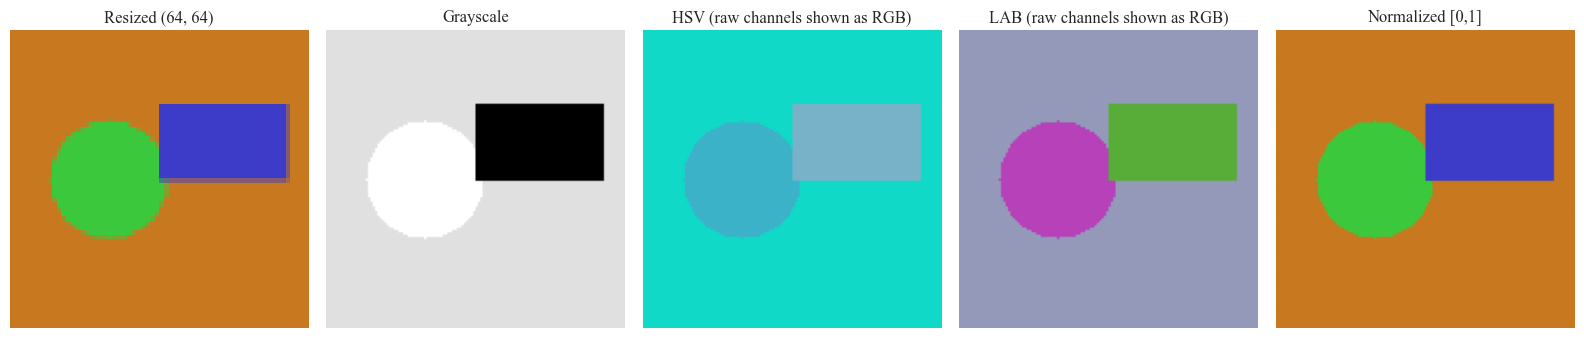

In [ ]:
resized = cv2.resize(image_rgb, (64, 64))
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
normalized = image_rgb.astype(np.float32) / 255.0            # x' = x / 255

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
axes[0].imshow(resized); axes[0].set_title(f"Resized {resized.shape[:2]}")
axes[1].imshow(gray, cmap="gray"); axes[1].set_title("Grayscale")
axes[2].imshow(hsv); axes[2].set_title("HSV (raw channels shown as RGB)")
axes[3].imshow(lab); axes[3].set_title("LAB (raw channels shown as RGB)")
axes[4].imshow(normalized); axes[4].set_title("Normalized [0,1]")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Per-channel standardization:**
$$
x'' = \frac{x - \mu_{\text{channel}}}{\sigma_{\text{channel}}}
$$

In [ ]:
channel_means = normalized.reshape(-1, 3).mean(axis=0)
channel_stds = normalized.reshape(-1, 3).std(axis=0)
standardized_img = (normalized - channel_means) / channel_stds

print("Per-channel means (R,G,B):", np.round(channel_means, 3))
print("Per-channel stds  (R,G,B):", np.round(channel_stds, 3))
print("Standardized image value range:", standardized_img.min().round(2), "to", standardized_img.max().round(2))

Per-channel means (R,G,B): [0.659 0.482 0.205]
Per-channel stds  (R,G,B): [0.231 0.133 0.208]
Standardized image value range: -1.86 to 2.79


**Interpretation.** Resizing produces a fixed-size tensor (required because most CNN architectures
expect a fixed input shape). Grayscale collapses color information, useful when shape/texture matters
more than color (e.g., some defect-inspection tasks). HSV separates color (Hue) from intensity
(Value) — useful for tasks like segmenting objects by color under varying lighting. LAB separates
lightness from color, and is often preferred for perceptually-uniform color comparisons. Per-channel
standardization (using ImageNet-style or dataset-specific channel statistics) is the standard input
normalization for CNNs.

**Takeaway.** *Which* color representation to preprocess into is itself a modeling decision, not a
default — pick the one that exposes the signal your task needs.

## Section 10 — Image Augmentation

Augmentation artificially expands the *training* set's diversity by applying label-preserving
transformations. It should **never** be applied to validation/test data — those must reflect realistic
deployment conditions.

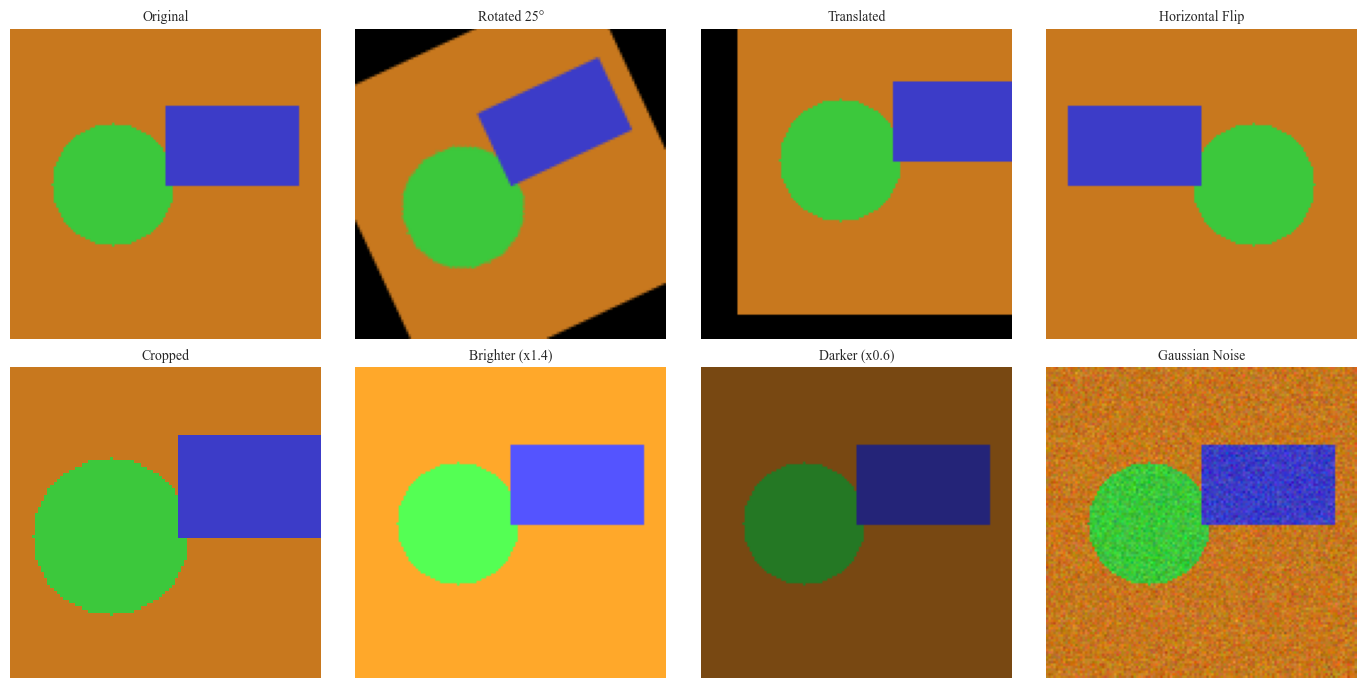

In [ ]:
def rotate(img, angle):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h))

def translate(img, tx, ty):
    h, w = img.shape[:2]
    M = np.float32([[1, 0, tx], [0, 1, ty]])
    return cv2.warpAffine(img, M, (w, h))

def adjust_brightness(img, factor):
    return np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)

def add_noise(img, sigma=15):
    noise = np.random.normal(0, sigma, img.shape)
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

augmentations = {
    "Original": image_rgb,
    "Rotated 25°": rotate(image_rgb, 25),
    "Translated": translate(image_rgb, 15, -10),
    "Horizontal Flip": cv2.flip(image_rgb, 1),
    "Cropped": image_rgb[10:110, 10:110],
    "Brighter (x1.4)": adjust_brightness(image_rgb, 1.4),
    "Darker (x0.6)": adjust_brightness(image_rgb, 0.6),
    "Gaussian Noise": add_noise(image_rgb),
}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, (title, img) in zip(axes.ravel(), augmentations.items()):
    ax.imshow(img)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

> **Common Mistake — Augmenting validation/test data.** Augmentation is a *training-time* technique
> meant to teach the model invariances (e.g., "a rotated cat is still a cat"). Validation and test sets
> exist to estimate real-world performance — artificially augmenting them would answer the wrong
> question ("how well does the model do on augmented images?") instead of the right one ("how well
> will the model do in deployment?").

**Takeaway.**
```
Training augmentation   → applied only to the training split, increases diversity
Validation/Test data    → left as close to real deployment conditions as possible
```

## Section 11 — Image-Specific Processing

We demonstrate denoising, sharpening, and histogram equalization — techniques directly relevant to
**medical imaging**, **agricultural imagery**, and **industrial surface-defect inspection** (the kind
of task in the [[impeller-defect-paper]] classification setting: subtle surface defects need contrast
enhancement and denoising *before* a CNN can reliably separate defect from non-defect texture).

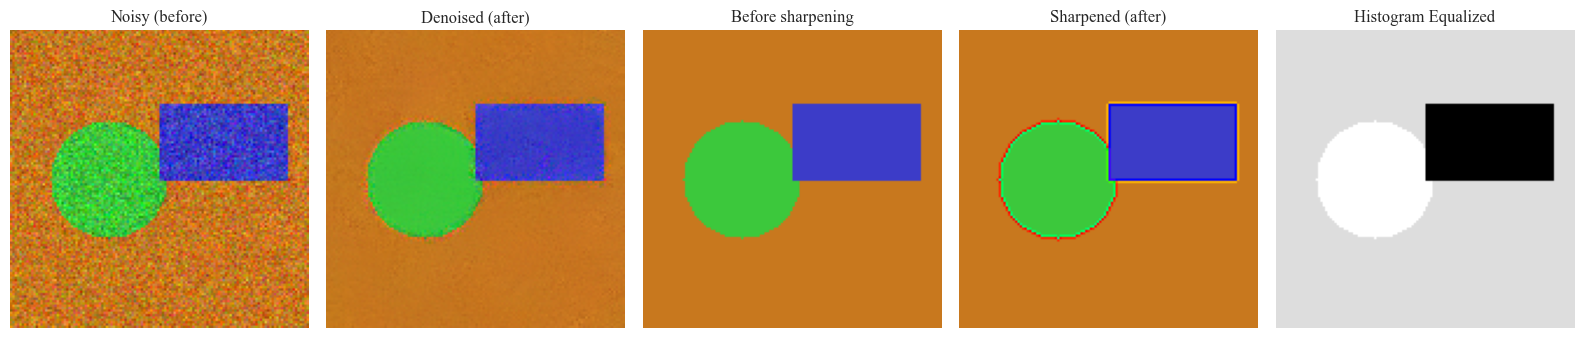

In [ ]:
noisy_image = add_noise(image_rgb, sigma=25)
denoised = cv2.fastNlMeansDenoisingColored(noisy_image, None, 10, 10, 7, 21)

sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened = cv2.filter2D(image_rgb, -1, sharpen_kernel)

gray_for_eq = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
equalized = cv2.equalizeHist(gray_for_eq)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
axes[0].imshow(noisy_image); axes[0].set_title("Noisy (before)")
axes[1].imshow(denoised); axes[1].set_title("Denoised (after)")
axes[2].imshow(image_rgb); axes[2].set_title("Before sharpening")
axes[3].imshow(sharpened); axes[3].set_title("Sharpened (after)")
axes[4].imshow(equalized, cmap="gray"); axes[4].set_title("Histogram Equalized")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

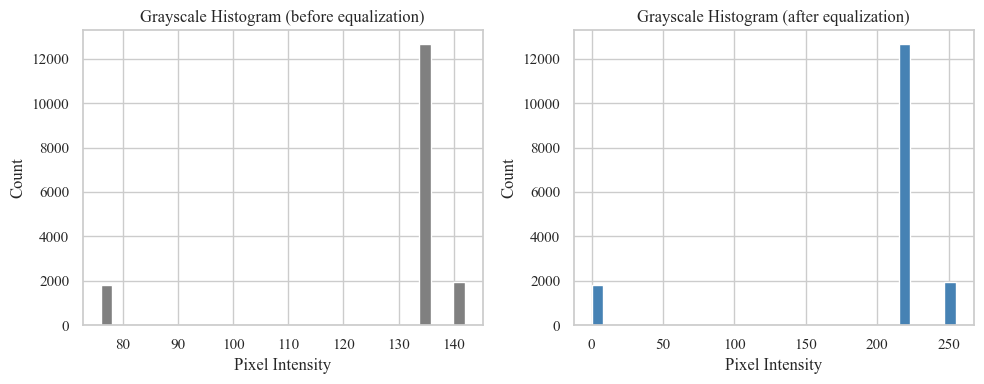

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(gray_for_eq.ravel(), bins=32, color="gray")
axes[0].set_title("Grayscale Histogram (before equalization)")
axes[0].set_xlabel("Pixel Intensity"); axes[0].set_ylabel("Count")

axes[1].hist(equalized.ravel(), bins=32, color="steelblue")
axes[1].set_title("Grayscale Histogram (after equalization)")
axes[1].set_xlabel("Pixel Intensity"); axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

**Interpretation.** Denoising (non-local means) smooths sensor/compression noise while trying to
preserve edges — critical in medical imaging where noise can be mistaken for tissue texture. Sharpening
emphasizes edges — useful for highlighting fine surface cracks in industrial inspection. Histogram
equalization redistributes pixel intensities to use the full dynamic range — it can reveal
low-contrast defects (e.g., a faint casting flaw) that are barely visible in the raw image, which is
directly relevant to CNN-based surface-defect classification pipelines.

**Takeaway.** Each of these is a *deliberate* preprocessing choice tied to what the downstream model
needs to see clearly — applying all of them blindly can just as easily destroy signal as reveal it.

## Section 12 — NLP Preprocessing

```
Raw Text
   ↓
Cleaning
   ↓
Tokenization
   ↓
Representation
   ↓
Model
```

We keep this section dependency-light (no NLTK/spaCy install required) using straightforward Python
string operations, which is all the lecture's cleaning/tokenization steps need.

In [ ]:
import re
import string

corpus = [
    "The CNN model achieved 96% accuracy on the surface-defect dataset!!",
    "Preprocessing, feature engineering, and data cleaning are NOT the same thing.",
    "Gradient   descent    can zig-zag  when features aren't scaled properly...",
    "Neural networks learn representations; classical ML often needs hand-crafted features.",
]

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

cleaned_corpus = [clean_text(doc) for doc in corpus]
for raw, clean in zip(corpus, cleaned_corpus):
    print(f"RAW  : {raw}")
    print(f"CLEAN: {clean}\n")

RAW  : The CNN model achieved 96% accuracy on the surface-defect dataset!!
CLEAN: the cnn model achieved 96 accuracy on the surfacedefect dataset

RAW  : Preprocessing, feature engineering, and data cleaning are NOT the same thing.
CLEAN: preprocessing feature engineering and data cleaning are not the same thing

RAW  : Gradient   descent    can zig-zag  when features aren't scaled properly...
CLEAN: gradient descent can zigzag when features arent scaled properly

RAW  : Neural networks learn representations; classical ML often needs hand-crafted features.
CLEAN: neural networks learn representations classical ml often needs handcrafted features



In [ ]:
stopwords = {"the", "a", "an", "and", "or", "is", "are", "on", "in", "of", "not", "can", "when", "often"}

def word_tokenize(text):
    return text.split()

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stopwords]

tokenized = [word_tokenize(doc) for doc in cleaned_corpus]
no_stopwords = [remove_stopwords(toks) for toks in tokenized]

vocabulary = sorted(set(tok for doc in no_stopwords for tok in doc))
print(f"Vocabulary size (after stopword removal): {len(vocabulary)}")
print(vocabulary)

Vocabulary size (after stopword removal): 29
['96', 'accuracy', 'achieved', 'arent', 'classical', 'cleaning', 'cnn', 'data', 'dataset', 'descent', 'engineering', 'feature', 'features', 'gradient', 'handcrafted', 'learn', 'ml', 'model', 'needs', 'networks', 'neural', 'preprocessing', 'properly', 'representations', 'same', 'scaled', 'surfacedefect', 'thing', 'zigzag']


### Three levels of tokenization

In [ ]:
sample = cleaned_corpus[0]

word_level = sample.split()
char_level = list(sample.replace(" ", ""))

def simple_subword_tokenize(text, vocab_pieces):
    # simplified illustrative BPE-style greedy matcher (not a full BPE implementation)
    tokens = []
    for word in text.split():
        i = 0
        pieces = []
        while i < len(word):
            match = None
            for j in range(len(word), i, -1):
                piece = word[i:j]
                if piece in vocab_pieces:
                    match = piece
                    break
            if match is None:
                match = word[i]
            pieces.append(match)
            i += len(match)
        tokens.extend(pieces)
    return tokens

toy_subword_vocab = {"cnn", "model", "ach", "iev", "ed", "ac", "cur", "acy", "on", "the",
                      "sur", "face", "defect", "data", "set"}
subword_level = simple_subword_tokenize(sample, toy_subword_vocab)

print("Word-level   :", word_level)
print("Char-level   :", char_level[:20], "...")
print("Subword-level:", subword_level)

Word-level   : ['the', 'cnn', 'model', 'achieved', '96', 'accuracy', 'on', 'the', 'surfacedefect', 'dataset']
Char-level   : ['t', 'h', 'e', 'c', 'n', 'n', 'm', 'o', 'd', 'e', 'l', 'a', 'c', 'h', 'i', 'e', 'v', 'e', 'd', '9'] ...
Subword-level: ['the', 'cnn', 'model', 'ach', 'iev', 'ed', '9', '6', 'ac', 'cur', 'acy', 'on', 'the', 'sur', 'face', 'defect', 'data', 'set']


**Why do modern Transformers favor subword tokenization?** Word-level tokenization produces huge
vocabularies and cannot handle unseen/rare words (out-of-vocabulary problem). Character-level
tokenization avoids OOV entirely but produces very long sequences and loses word-level meaning per
token. **Subword tokenization** (BPE, WordPiece, SentencePiece) is the practical middle ground: common
words stay as single tokens, rare/unseen words decompose into meaningful sub-pieces, and vocabulary
size stays bounded — which is why GPT, BERT, and similar models all use it.

## Section 13 — Text Representations

**Conceptual progression:**
```
Counts  →  TF-IDF  →  Static Embeddings  →  Contextual Embeddings
```

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

count_vectorizer = CountVectorizer(stop_words="english")
bow_matrix = count_vectorizer.fit_transform(cleaned_corpus)
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=count_vectorizer.get_feature_names_out())
print("Bag-of-Words vocabulary size:", len(count_vectorizer.get_feature_names_out()))
bow_df

Bag-of-Words vocabulary size: 28


,96,accuracy,achieved,arent,classical,cleaning,cnn,data,dataset,descent,...,needs,networks,neural,preprocessing,properly,representations,scaled,surfacedefect,thing,zigzag
0,1,1,1,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,1,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,0,0,1,0,0,0,0,0,1,...,0,0,0,0,1,0,1,0,0,1
3,0,0,0,0,1,0,0,0,0,0,...,1,1,1,0,0,1,0,0,0,0


In [ ]:
tfidf_vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf_vectorizer.fit_transform(cleaned_corpus)
tfidf_df = pd.DataFrame(np.round(tfidf_matrix.toarray(), 2), columns=tfidf_vectorizer.get_feature_names_out())

sparsity = 1.0 - (tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]))
print(f"Document-term matrix shape: {tfidf_matrix.shape}")
print(f"Sparsity: {sparsity:.2%}")
tfidf_df

Document-term matrix shape: (4, 28)
Sparsity: 74.11%


,96,accuracy,achieved,arent,classical,cleaning,cnn,data,dataset,descent,...,needs,networks,neural,preprocessing,properly,representations,scaled,surfacedefect,thing,zigzag
0,0.38,0.38,0.38,0.00,0.00,0.00,0.38,0.00,0.38,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.38,0.00,0.00
1,0.00,0.00,0.00,0.00,0.00,0.41,0.00,0.41,0.00,0.00,...,0.00,0.00,0.00,0.41,0.00,0.00,0.00,0.00,0.41,0.00
2,0.00,0.00,0.00,0.39,0.00,0.00,0.00,0.00,0.00,0.39,...,0.00,0.00,0.00,0.00,0.39,0.00,0.39,0.00,0.00,0.39
3,0.00,0.00,0.00,0.00,0.34,0.00,0.00,0.00,0.00,0.00,...,0.34,0.34,0.34,0.00,0.00,0.34,0.00,0.00,0.00,0.00


**Interpretation.** Bag-of-Words counts raw term frequency — a word appearing often in *every*
document (like "the") gets a high count but carries little discriminative signal. TF-IDF down-weights
terms that appear across many documents and up-weights terms distinctive to a specific document — that
is exactly what "IDF" (inverse document frequency) does. Both representations are extremely sparse:
most vocabulary words don't appear in most documents, wasting memory and giving the model very little
to generalize from for rare words.

**Static embeddings** (e.g., Word2Vec, GloVe) replace sparse counts with dense, low-dimensional vectors
where semantically similar words end up close together — but each word gets exactly *one* vector
regardless of context. **Contextual embeddings** (e.g., BERT, GPT-family models) produce a *different*
vector for the same word depending on its surrounding sentence, capturing polysemy ("bank" of a river
vs. a "bank" account). This notebook does not require a pretrained embedding model to run, but you're
encouraged to try loading a small one (e.g., `gensim`'s `glove-wiki-gigaword-50`) if you have internet
access, to see nearest-neighbor words.

**Takeaway.** Moving from Counts → TF-IDF → embeddings is a move from *sparse, hand-designed* features
toward *dense, learned* representations — the same conceptual story as Section 20.

## Section 14 — Sequence and Time-Series Preprocessing

We build a synthetic time series with trend, seasonality, noise, and gaps — then clean and preprocess
it the way the lecture demonstrates: sort, resample, interpolate, smooth, normalize, difference,
detrend.

In [ ]:
np.random.seed(RANDOM_STATE)
periods = 200
timestamps = pd.date_range("2025-01-01", periods=periods, freq="D")
trend = np.linspace(10, 40, periods)
seasonality = 5 * np.sin(np.linspace(0, 8 * np.pi, periods))
noise = np.random.normal(0, 1.5, periods)
values = trend + seasonality + noise

ts = pd.DataFrame({"timestamp": timestamps, "value": values})

# shuffle rows out of order, then inject missing timestamps and missing values
ts = ts.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
drop_idx = np.random.choice(ts.index, size=15, replace=False)
ts = ts.drop(index=drop_idx).reset_index(drop=True)
nan_idx = np.random.choice(ts.index, size=10, replace=False)
ts.loc[nan_idx, "value"] = np.nan

print(f"Rows (out of order, with gaps): {len(ts)}")
ts.head()

Rows (out of order, with gaps): 185


,timestamp,value
0,2025-04-06,19.435216
1,2025-01-16,16.158309
2,2025-01-31,10.605028
3,2025-06-08,NaN
4,2025-05-09,27.235991


After resampling to daily frequency: 200 rows, 25 missing values


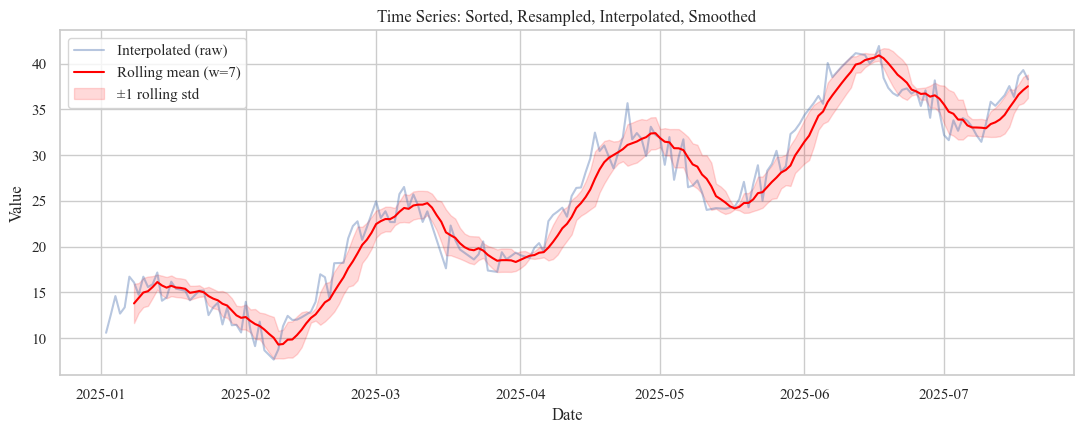

In [ ]:
# 1. Sort chronologically
ts_sorted = ts.sort_values("timestamp").set_index("timestamp")

# 2. Resample to a regular daily frequency (reveals missing timestamps as new NaN rows)
ts_resampled = ts_sorted.resample("D").mean()
print(f"After resampling to daily frequency: {len(ts_resampled)} rows, "
      f"{ts_resampled['value'].isna().sum()} missing values")

# 3. Interpolate missing values
ts_interpolated = ts_resampled.interpolate(method="linear")

# 4. Smoothing / rolling mean and rolling std (denoising)
ts_interpolated["rolling_mean_7"] = ts_interpolated["value"].rolling(window=7).mean()
ts_interpolated["rolling_std_7"] = ts_interpolated["value"].rolling(window=7).std()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(ts_interpolated.index, ts_interpolated["value"], alpha=0.4, label="Interpolated (raw)")
ax.plot(ts_interpolated.index, ts_interpolated["rolling_mean_7"], color="red", label="Rolling mean (w=7)")
ax.fill_between(ts_interpolated.index,
                 ts_interpolated["rolling_mean_7"] - ts_interpolated["rolling_std_7"],
                 ts_interpolated["rolling_mean_7"] + ts_interpolated["rolling_std_7"],
                 color="red", alpha=0.15, label="±1 rolling std")
ax.set_title("Time Series: Sorted, Resampled, Interpolated, Smoothed")
ax.set_xlabel("Date"); ax.set_ylabel("Value"); ax.legend()
plt.tight_layout()
plt.show()

**Differencing** (removes trend, a step toward stationarity):
$$
\Delta x_t = x_t - x_{t-1}
$$

**Rolling mean** over window $w$:
$$
\mu_t^{(w)} = \frac{1}{w}\sum_{i=0}^{w-1} x_{t-i}
$$

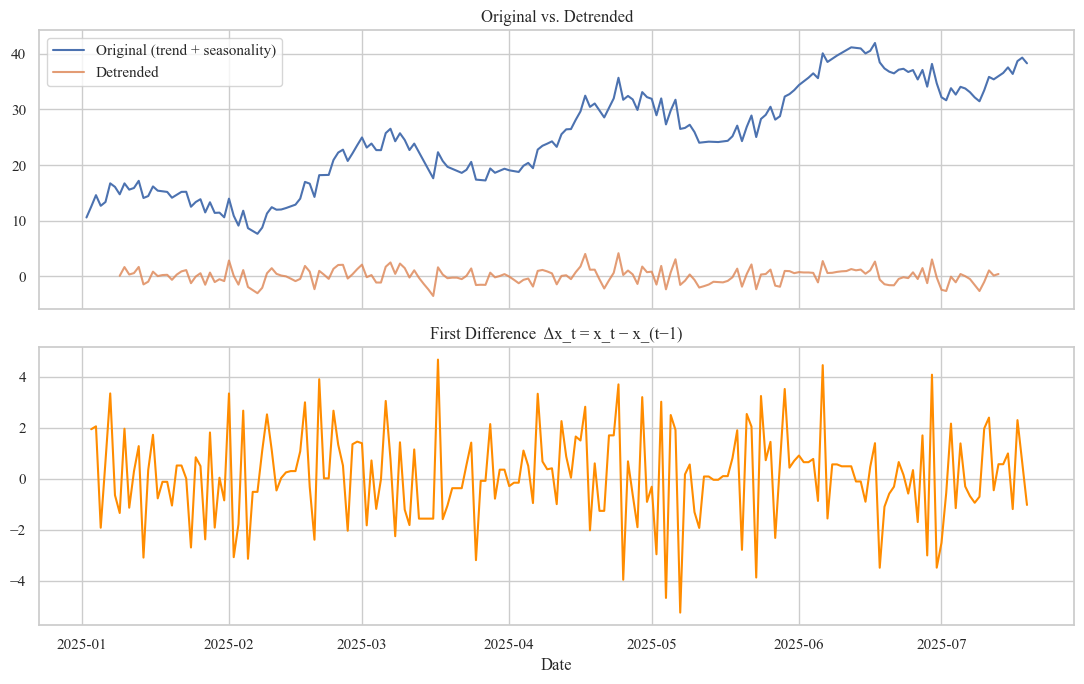

,value,lag_1,lag_7,rolling_mean_7,diff_1
timestamp,,,,,
2025-01-09,14.736939,16.073045,10.573156,14.379221,-1.336106
2025-01-10,16.706785,14.736939,12.522605,14.976961,1.969846
2025-01-11,15.577356,16.706785,14.586233,15.118550,-1.129430
2025-01-12,15.877523,15.577356,12.671613,15.576537,0.300167
2025-01-13,17.164358,15.877523,13.354247,16.120838,1.286836


In [ ]:
ts_interpolated["diff_1"] = ts_interpolated["value"].diff()
ts_interpolated["detrended"] = ts_interpolated["value"] - ts_interpolated["value"].rolling(window=14, center=True).mean()
ts_interpolated["normalized"] = (ts_interpolated["value"] - ts_interpolated["value"].mean()) / ts_interpolated["value"].std()

for lag in [1, 7]:
    ts_interpolated[f"lag_{lag}"] = ts_interpolated["value"].shift(lag)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(ts_interpolated.index, ts_interpolated["value"], label="Original (trend + seasonality)")
axes[0].plot(ts_interpolated.index, ts_interpolated["detrended"], label="Detrended", alpha=0.8)
axes[0].set_title("Original vs. Detrended"); axes[0].legend()

axes[1].plot(ts_interpolated.index, ts_interpolated["diff_1"], color="darkorange")
axes[1].set_title("First Difference  Δx_t = x_t − x_(t−1)")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

ts_interpolated[["value", "lag_1", "lag_7", "rolling_mean_7", "diff_1"]].dropna().head()

**Interpretation.** Sorting is a prerequisite for *everything* that follows — rolling statistics on an
out-of-order series are meaningless. Resampling to a regular frequency exposes missing timestamps that
were invisible in the raw (irregular) row order. Differencing removes the trend component, which is
often required before applying models that assume stationarity. Lag features and rolling statistics
turn history into explicit input columns a standard (non-recurrent) model can consume.

**Takeaway.** For time series, "clean" doesn't just mean "no NaNs" — it means chronologically ordered,
regularly spaced, and stationary-if-required.

## Section 15 — Sliding Windows

A time series becomes a supervised-learning problem by sliding a fixed-size window across it:

```
[x1, x2, x3, x4, x5] → x6
[x2, x3, x4, x5, x6] → x7
[x3, x4, x5, x6, x7] → x8
```

In [ ]:
def create_sliding_windows(series, window_size, horizon=1):
    """Convert a 1D series into (X, y) supervised pairs using a look-back window.

    Parameters
    ----------
    series : array-like, the time-ordered values
    window_size : int, the look-back period (number of past steps used as input)
    horizon : int, how many steps ahead to forecast

    Returns
    -------
    X : ndarray of shape (n_windows, window_size)
    y : ndarray of shape (n_windows,)
    """
    series = np.asarray(series)
    X, y = [], []
    for i in range(len(series) - window_size - horizon + 1):
        X.append(series[i : i + window_size])
        y.append(series[i + window_size + horizon - 1])
    return np.array(X), np.array(y)

clean_values = ts_interpolated["value"].values
X_windows, y_windows = create_sliding_windows(clean_values, window_size=5, horizon=1)
print(f"Generated {X_windows.shape[0]} windows of look-back {X_windows.shape[1]}")
print("First 3 windows (X) -> target (y):")
for i in range(3):
    print(f"  {np.round(X_windows[i], 2)} -> {y_windows[i]:.2f}")

Generated 195 windows of look-back 5
First 3 windows (X) -> target (y):
  [  nan 10.57 12.52 14.59 12.67] -> 13.35
  [10.57 12.52 14.59 12.67 13.35] -> 16.71
  [12.52 14.59 12.67 13.35 16.71] -> 16.07


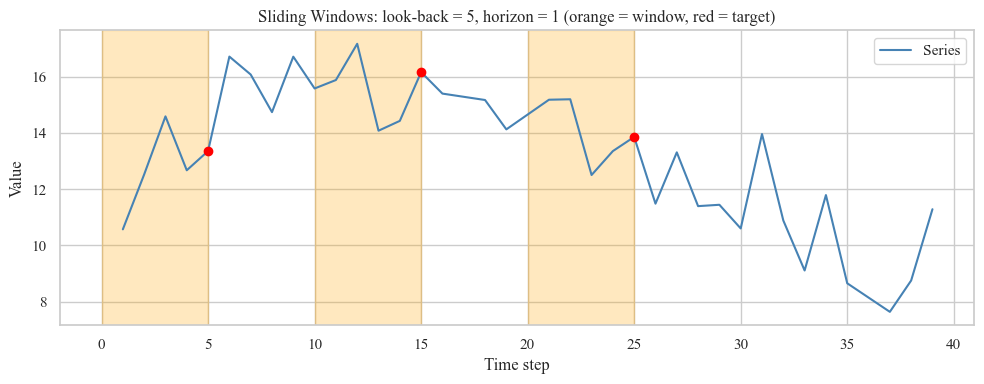

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(clean_values[:40], color="steelblue", label="Series")
for start in [0, 10, 20]:
    ax.axvspan(start, start + 5, color="orange", alpha=0.25)
    ax.scatter(start + 5, clean_values[start + 5], color="red", zorder=5)
ax.set_title("Sliding Windows: look-back = 5, horizon = 1 (orange = window, red = target)")
ax.set_xlabel("Time step"); ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()

**Terminology.**
- **Look-back period** — how many past steps the model sees (`window_size`)
- **Forecasting horizon** — how many steps ahead the target is (`horizon`)
- **Padding** — filling missing steps at series boundaries (e.g., with zeros) when a fixed window size
  is required at the very start of a series
- **Masking** — flagging padded/missing positions so a model can learn to ignore them, common in
  variable-length sequence models

## Section 16 — Temporal Leakage

**Why random splitting is dangerous for time series.** A random `train_test_split` can place a row
from *day 50* in the training set and a row from *day 10* in the test set. The model then implicitly
has access to "future" information relative to some of its test predictions — a form of leakage
specific to temporal data.

In [ ]:
n_rows = len(ts_interpolated)
split_point = int(n_rows * 0.8)

# INCORRECT: random split ignores time order
train_random, test_random = train_test_split(ts_interpolated.reset_index(), test_size=0.2, random_state=RANDOM_STATE)
print("Random split — max date in TRAIN:", train_random["timestamp"].max().date())
print("Random split — min date in TEST :", test_random["timestamp"].min().date())
print("-> Test set contains dates that occur BEFORE some training dates:",
      test_random["timestamp"].min() < train_random["timestamp"].max())

# CORRECT: chronological split
train_chrono = ts_interpolated.iloc[:split_point]
test_chrono = ts_interpolated.iloc[split_point:]
print("\nChronological split — max date in TRAIN:", train_chrono.index.max().date())
print("Chronological split — min date in TEST :", test_chrono.index.min().date())
print("-> All test dates occur strictly after all training dates:",
      test_chrono.index.min() > train_chrono.index.max())

Random split — max date in TRAIN: 2025-07-19
Random split — min date in TEST : 2025-01-10
-> Test set contains dates that occur BEFORE some training dates: True

Chronological split — max date in TRAIN: 2025-06-09
Chronological split — min date in TEST : 2025-06-10
-> All test dates occur strictly after all training dates: True


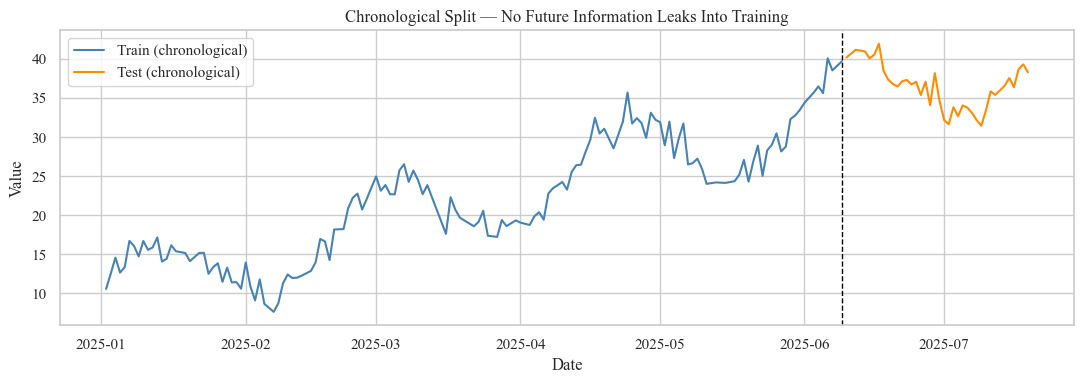

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(train_chrono.index, train_chrono["value"], label="Train (chronological)", color="steelblue")
ax.plot(test_chrono.index, test_chrono["value"], label="Test (chronological)", color="darkorange")
ax.axvline(train_chrono.index.max(), color="black", linestyle="--", linewidth=1)
ax.set_title("Chronological Split — No Future Information Leaks Into Training")
ax.set_xlabel("Date"); ax.set_ylabel("Value"); ax.legend()
plt.tight_layout()
plt.show()

**Takeaway.** Time-series data must be split **chronologically**: training data strictly precedes
validation/test data in time. This prevents the model from "seeing the future" during training and
keeps the evaluation an honest estimate of forecasting performance.

> **Data Leakage Warning** — This applies to *every* preprocessing statistic computed on time
> series too: a rolling mean or scaler fit using future rows relative to a given prediction point is
> temporal leakage, even if the train/test split itself was done correctly.

## Section 17 — Feature Engineering: Creation

```
Raw Variables
      ↓
Feature Engineering
      ↓
Predictive Representation
```

The lecture defines **feature engineering** as the deliberate construction, transformation, selection,
or representation of input variables to make predictive information more accessible to a model.

**Feature creation** examples — ratios, differences, and domain-specific combinations:
$$
BMI = \frac{weight}{height^2} \qquad
profit = revenue - cost \qquad
age = \text{current year} - \text{birth year}
$$

In [ ]:
fe_demo = pd.DataFrame({
    "weight_kg": [65, 80, 55, 90, 72],
    "height_m": [1.65, 1.80, 1.60, 1.75, 1.70],
    "revenue": [12000, 15500, 9800, 21000, 13400],
    "cost": [8000, 11000, 7200, 16500, 9700],
    "birth_year": [1998, 1990, 2001, 1985, 1995],
})
current_year = 2026

fe_demo["BMI"] = fe_demo["weight_kg"] / (fe_demo["height_m"] ** 2)
fe_demo["profit"] = fe_demo["revenue"] - fe_demo["cost"]
fe_demo["age"] = current_year - fe_demo["birth_year"]
fe_demo["profit_margin"] = fe_demo["profit"] / fe_demo["revenue"]   # ratio feature
fe_demo["revenue_x_age"] = fe_demo["revenue"] * fe_demo["age"]      # interaction feature

fe_demo

,weight_kg,height_m,revenue,cost,birth_year,BMI,profit,age,profit_margin,revenue_x_age
0,65,1.65,12000,8000,1998,23.875115,4000,28,0.333333,336000
1,80,1.80,15500,11000,1990,24.691358,4500,36,0.290323,558000
2,55,1.60,9800,7200,2001,21.484375,2600,25,0.265306,245000
3,90,1.75,21000,16500,1985,29.387755,4500,41,0.214286,861000
4,72,1.70,13400,9700,1995,24.913495,3700,31,0.276119,415400


> **Key Idea** — Every engineered feature above encodes *domain knowledge* the raw columns didn't
> expose directly (e.g., `profit_margin` is far more comparable across companies of different sizes
> than raw `profit`).

## Section 18 — Feature Transformation

Skewed distributions can hurt linear models and slow optimization. We compare log, square-root,
Yeo-Johnson, and quantile transforms on a synthetic right-skewed feature.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:2785: UserWarning: n_quantiles (1000) is greater than the total number of samples (500). n_quantiles is set to n_samples.
  warnings.warn(


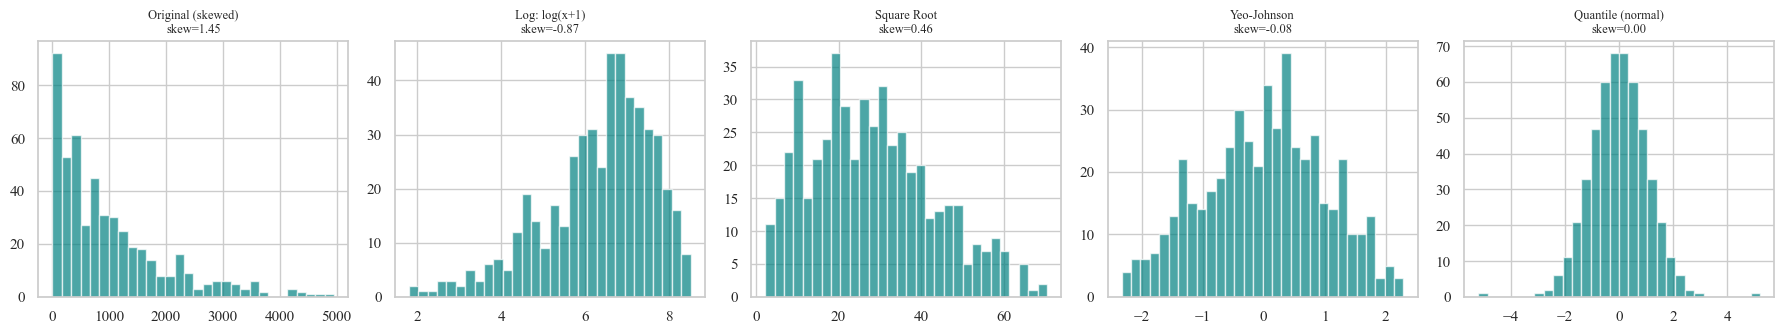

In [ ]:
np.random.seed(RANDOM_STATE)
skewed = np.random.exponential(scale=1000, size=500)

log_transformed = np.log1p(skewed)                 # x' = log(x + 1)
sqrt_transformed = np.sqrt(skewed)                 # x' = sqrt(x)

pt_yeo = PowerTransformer(method="yeo-johnson")
yeo_transformed = pt_yeo.fit_transform(skewed.reshape(-1, 1)).ravel()

from sklearn.preprocessing import QuantileTransformer
qt = QuantileTransformer(output_distribution="normal", random_state=RANDOM_STATE)
quantile_transformed = qt.fit_transform(skewed.reshape(-1, 1)).ravel()

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
data_to_plot = {
    "Original (skewed)": skewed,
    "Log: log(x+1)": log_transformed,
    "Square Root": sqrt_transformed,
    "Yeo-Johnson": yeo_transformed,
    "Quantile (normal)": quantile_transformed,
}
for ax, (title, data) in zip(axes, data_to_plot.items()):
    ax.hist(data, bins=30, color="teal", alpha=0.7)
    ax.set_title(f"{title}\nskew={pd.Series(data).skew():.2f}", fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation.** The raw feature is heavily right-skewed (skewness far above 0). Log and square-root
transforms compress large values proportionally more than small ones, reducing skew — log more
aggressively than sqrt. Yeo-Johnson (a generalization of Box-Cox that also handles zero/negative
values, unlike Box-Cox which requires strictly positive input) and quantile transforms both actively
search for the transform that best normalizes the distribution.

**Takeaway.** Transformations can reduce skew, stabilize variance, improve linear separability, and
improve optimization conditioning (Section 2) — but they should be chosen based on *what the
distribution actually looks like*, not applied by default to every numeric column.

> **Data Leakage Warning** — `PowerTransformer` and `QuantileTransformer` both learn statistics from
> the data (like a scaler). Fit them on training data only, exactly like `StandardScaler` in Section 7.

## Section 19 — Feature Selection

Feature selection is organized into three families: **filter**, **wrapper**, and **embedded**
methods.

In [ ]:
from sklearn.datasets import make_classification
from sklearn.feature_selection import (
    SelectKBest, mutual_info_classif, VarianceThreshold, RFE
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X_fs, y_fs = make_classification(
    n_samples=400, n_features=12, n_informative=5, n_redundant=3,
    random_state=RANDOM_STATE
)
feature_names = [f"f{i}" for i in range(X_fs.shape[1])]
X_fs_df = pd.DataFrame(X_fs, columns=feature_names)

# ---- Filter methods ----
correlations = X_fs_df.corrwith(pd.Series(y_fs)).abs().sort_values(ascending=False)
variances = X_fs_df.var().sort_values(ascending=False)
mi_scores = pd.Series(mutual_info_classif(X_fs, y_fs, random_state=RANDOM_STATE), index=feature_names).sort_values(ascending=False)

print("Top features by |correlation| with target:\n", correlations.head(5), "\n")
print("Top features by mutual information:\n", mi_scores.head(5))

Top features by |correlation| with target:
 f0     0.474444
f6     0.430349
f9     0.330244
f11    0.329404
f4     0.319966
dtype: float64 

Top features by mutual information:
 f0    0.150835
f4    0.120076
f9    0.117494
f6    0.106513
f2    0.105703
dtype: float64


In [ ]:
# ---- Wrapper method: Recursive Feature Elimination ----
rfe_estimator = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
rfe = RFE(rfe_estimator, n_features_to_select=5)
rfe.fit(X_fs, y_fs)
rfe_selected = [f for f, keep in zip(feature_names, rfe.support_) if keep]
print("RFE-selected features:", rfe_selected)

# ---- Embedded methods: L1 regularization + tree-based importance ----
l1_model = LogisticRegression(penalty="l1", solver="liblinear", C=0.3, random_state=RANDOM_STATE)
l1_model.fit(X_fs, y_fs)
l1_selected = [f for f, c in zip(feature_names, l1_model.coef_[0]) if abs(c) > 1e-6]
print("L1-selected (non-zero coefficient) features:", l1_selected)

rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_fs, y_fs)
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
print("\nTop features by Random Forest importance:\n", importances.head(5))

RFE-selected features: ['f0', 'f4', 'f7', 'f9', 'f11']
L1-selected (non-zero coefficient) features: ['f0', 'f1', 'f3', 'f4', 'f7', 'f9', 'f10', 'f11']

Top features by Random Forest importance:
 f0     0.135809
f4     0.131374
f11    0.120907
f9     0.100602
f2     0.093883
dtype: float64


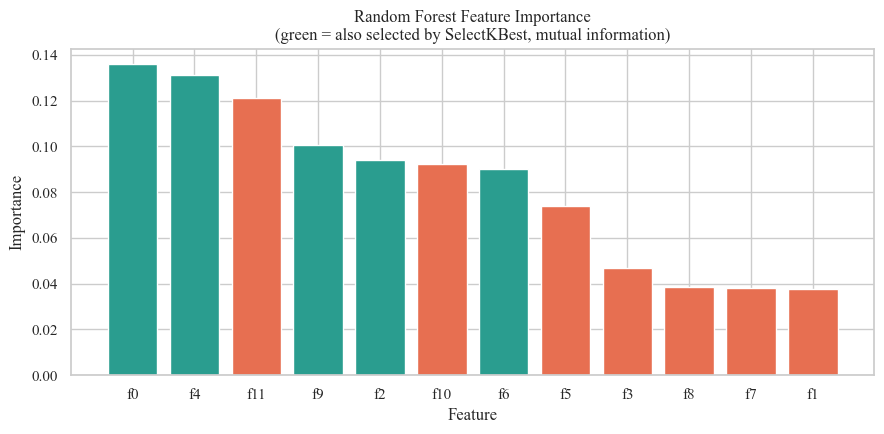

In [ ]:
kbest_selector = SelectKBest(score_func=mutual_info_classif, k=5)
kbest_selector.fit(X_fs, y_fs)
kbest_selected = set(np.array(feature_names)[kbest_selector.get_support()])

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#2a9d8f" if f in kbest_selected else "#e76f51" for f in importances.index]
ax.bar(importances.index, importances.values, color=colors)
ax.set_title("Random Forest Feature Importance\n(green = also selected by SelectKBest, mutual information)")
ax.set_xlabel("Feature"); ax.set_ylabel("Importance")
plt.tight_layout()
plt.show()

| Family | Idea | Examples used above |
|---|---|---|
| **Filter** | Score each feature independently of any model | correlation, variance, mutual information |
| **Wrapper** | Search feature subsets using actual model performance | Recursive Feature Elimination (RFE) |
| **Embedded** | Selection happens as part of model training | L1 (Lasso-style) regularization, tree importances |

> **Reflection** — Why does feature selection *not* necessarily improve model performance? Removing
> a weakly-informative feature can sometimes remove signal a more flexible model (e.g., a random
> forest) could have exploited in combination with other features — selection helps most when it
> reduces noise or overfitting risk, not automatically in every case. Section 37's Wine Quality
> experiment tests this empirically rather than assuming it.

> **Data Leakage Warning** — Every selector above (`SelectKBest`, `RFE`, L1 model, `RandomForestClassifier`
> used for importances) must be **fit on training data only**, exactly like a scaler.

## Section 20 — Representation Learning

```
Raw Data → Hand-Crafted Features        (Sections 17-19: features YOU design)
Raw Data → Learned Representation       (this section: features the MODEL discovers)
```

Formally, a representation-learning model learns a function $f_\theta(x) = z$ that maps raw input $x$
to a (usually lower-dimensional) representation $z$, optimized so that $z$ is useful for a downstream
task — without a human hand-designing $z$'s individual dimensions.

We demonstrate this with **PCA**, the simplest linear representation-learning technique: it learns a
projection that captures the directions of maximum variance in the data.

Original dimensionality: 13
Learned representation dimensionality: 2
Variance explained by 2 components: 55.41%


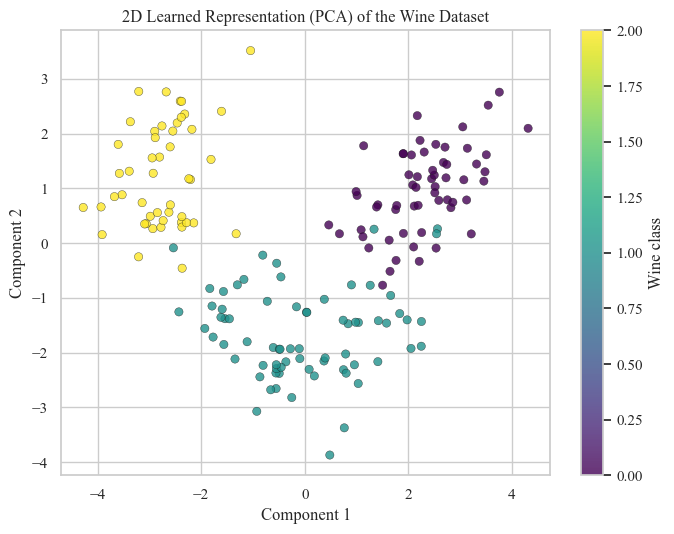

In [ ]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine

wine_raw = load_wine()
X_pca_input = StandardScaler().fit_transform(wine_raw.data)   # PCA is scale-sensitive -> standardize first
y_pca_labels = wine_raw.target

pca = PCA(n_components=2, random_state=RANDOM_STATE)
Z = pca.fit_transform(X_pca_input)

print(f"Original dimensionality: {X_pca_input.shape[1]}")
print(f"Learned representation dimensionality: {Z.shape[1]}")
print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(7, 5.5))
scatter = plt.scatter(Z[:, 0], Z[:, 1], c=y_pca_labels, cmap="viridis", alpha=0.8, edgecolor="k", linewidth=0.3)
plt.title("2D Learned Representation (PCA) of the Wine Dataset")
plt.xlabel("Component 1"); plt.ylabel("Component 2")
plt.colorbar(scatter, label="Wine class")
plt.tight_layout()
plt.show()

**Interpretation.** No human decided what "Component 1" or "Component 2" mean in domain terms — PCA
*learned* a 2-dimensional representation directly from the 13 original chemical measurements, and the
three wine classes are still visibly separable in that learned space. This is the core idea behind
representation learning at any scale, from PCA up through deep autoencoders and modern foundation
models: let an algorithm discover a useful representation rather than hand-crafting every feature.

**Takeaway.** Modern neural networks can learn representations automatically — but they don't remove
the need for good preprocessing (Sections 1-13) or thoughtful problem framing; they *add* another tool
alongside hand-crafted features rather than replacing the reasoning behind them.

## Section 21 — Cyclical Feature Engineering

**Concept.** `hour = 23` and `hour = 0` are one hour apart in reality, but as raw numbers they are 23
units apart — a model would see them as maximally different when they should be seen as neighbors.
Cyclical encoding fixes this using sine/cosine:
$$
x_{\sin} = \sin\!\left(\frac{2\pi x}{P}\right) \qquad
x_{\cos} = \cos\!\left(\frac{2\pi x}{P}\right)
$$
where $P$ is the period (24 for hour-of-day, 7 for day-of-week, 12 for month).

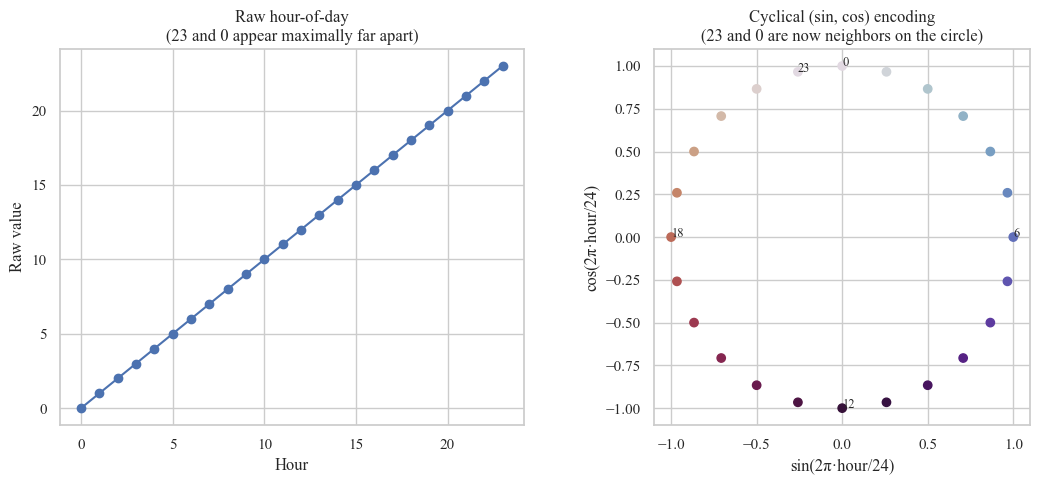

In [ ]:
hours = np.arange(0, 24)
hour_sin = np.sin(2 * np.pi * hours / 24)
hour_cos = np.cos(2 * np.pi * hours / 24)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].plot(hours, hours, "o-")
axes[0].set_title("Raw hour-of-day\n(23 and 0 appear maximally far apart)")
axes[0].set_xlabel("Hour"); axes[0].set_ylabel("Raw value")

axes[1].scatter(hour_sin, hour_cos, c=hours, cmap="twilight")
for h in [0, 6, 12, 18, 23]:
    axes[1].annotate(str(h), (hour_sin[h], hour_cos[h]), fontsize=9)
axes[1].set_title("Cyclical (sin, cos) encoding\n(23 and 0 are now neighbors on the circle)")
axes[1].set_xlabel("sin(2π·hour/24)"); axes[1].set_ylabel("cos(2π·hour/24)")
axes[1].set_aspect("equal")
plt.tight_layout()
plt.show()

In [ ]:
cyclical_demo = pd.DataFrame({"hour": hours})
cyclical_demo["hour_sin"] = np.sin(2 * np.pi * cyclical_demo["hour"] / 24)
cyclical_demo["hour_cos"] = np.cos(2 * np.pi * cyclical_demo["hour"] / 24)

for period_name, period_val, col in [("day_of_week", 7, "dow"), ("month", 12, "month")]:
    vals = np.arange(period_val)
    print(f"{period_name} (P={period_val}) sin/cos example:",
          np.round(np.sin(2 * np.pi * vals / period_val), 2)[:4], "...")

cyclical_demo.head()

day_of_week (P=7) sin/cos example: [0.   0.78 0.97 0.43] ...
month (P=12) sin/cos example: [0.   0.5  0.87 1.  ] ...


,hour,hour_sin,hour_cos
0,0,0.000000,1.000000
1,1,0.258819,0.965926
2,2,0.500000,0.866025
3,3,0.707107,0.707107
4,4,0.866025,0.500000


**Takeaway.** Cyclical encoding represents periodic variables better because it preserves the circular
*distance* between values — the last hour of one day and the first hour of the next are correctly
placed close together in the encoded space, unlike raw integer encoding.

## Section 22 — Domain and Structural Features

Domain knowledge often produces the single most valuable engineered features — more valuable than any
generic transformation. Examples across fields:

| Domain | Example structural/domain features |
|---|---|
| Engineering | distance, area, aspect ratio, rate of change, energy |
| Signal processing | frequency-domain statistics (e.g., dominant frequency, spectral energy) |
| Image analysis | aspect ratio of a bounding box, edge density, texture energy |
| Agriculture | vegetation index (e.g., NDVI-style band ratios), growth rate |
| Finance | rate of return, volatility (rolling std of returns), moving-average crossovers |

In [ ]:
# A small worked example: structural features from bounding boxes (image analysis / defect inspection)
boxes = pd.DataFrame({
    "width_px": [40, 120, 15, 60, 200],
    "height_px": [40, 30, 90, 60, 50],
})
boxes["area"] = boxes["width_px"] * boxes["height_px"]
boxes["aspect_ratio"] = boxes["width_px"] / boxes["height_px"]
boxes["perimeter"] = 2 * (boxes["width_px"] + boxes["height_px"])
boxes

,width_px,height_px,area,aspect_ratio,perimeter
0,40,40,1600,1.000000,160
1,120,30,3600,4.000000,300
2,15,90,1350,0.166667,210
3,60,60,3600,1.000000,240
4,200,50,10000,4.000000,500


> 💡 **Key Idea** — Good feature engineering comes from understanding the underlying system, not merely
> manipulating columns. A structural feature like `aspect_ratio` above encodes shape information a
> generic polynomial or interaction term would not reliably rediscover on its own.

## Section 23 — Self-Supervised Representations

```
Input → Encoder → Latent Representation → Decoder → Reconstruction
```

Self-supervised learning creates a training signal from the *data itself* (no human labels needed) —
for example, by asking a model to reconstruct its own input after passing it through a narrow
"bottleneck." If reconstruction succeeds, the bottleneck must have captured the input's essential
structure. We implement a minimal linear autoencoder from scratch (via PCA, which is mathematically a
linear autoencoder with a linear encoder/decoder and squared-error reconstruction loss) rather than
pulling in a deep-learning framework.

In [ ]:
X_ae_input = StandardScaler().fit_transform(wine_raw.data)

# "Encoder": project to a 2D latent space (bottleneck)
encoder = PCA(n_components=2, random_state=RANDOM_STATE)
latent = encoder.fit_transform(X_ae_input)

# "Decoder": project back up to the original dimensionality
reconstructed = encoder.inverse_transform(latent)

reconstruction_error = np.mean((X_ae_input - reconstructed) ** 2)
print(f"Original dimensionality : {X_ae_input.shape[1]}")
print(f"Latent (bottleneck) dim : {latent.shape[1]}")
print(f"Mean squared reconstruction error: {reconstruction_error:.4f}")

Original dimensionality : 13
Latent (bottleneck) dim : 2
Mean squared reconstruction error: 0.4459


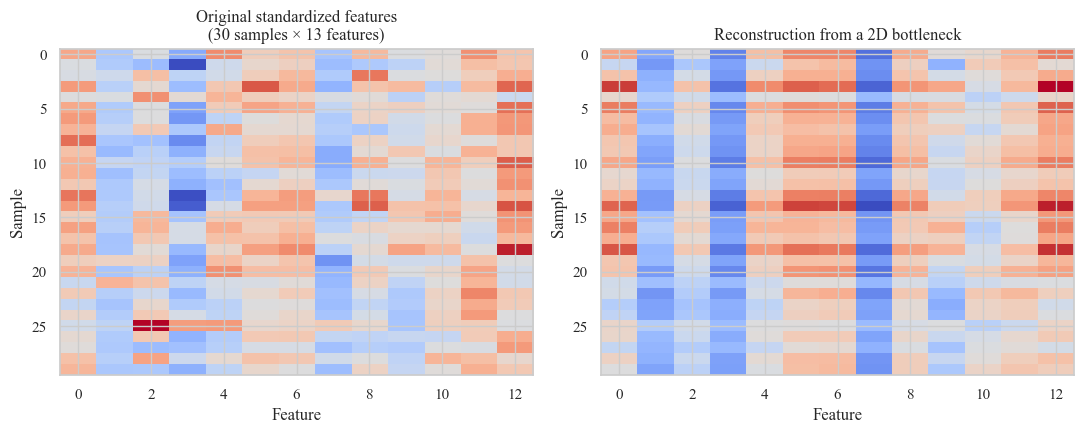

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].imshow(X_ae_input[:30], aspect="auto", cmap="coolwarm")
axes[0].set_title("Original standardized features\n(30 samples × 13 features)")
axes[0].set_xlabel("Feature"); axes[0].set_ylabel("Sample")

axes[1].imshow(reconstructed[:30], aspect="auto", cmap="coolwarm")
axes[1].set_title("Reconstruction from a 2D bottleneck")
axes[1].set_xlabel("Feature"); axes[1].set_ylabel("Sample")
plt.tight_layout()
plt.show()

**Interpretation.** The reconstruction from just 2 latent dimensions is imperfect (nonzero
reconstruction error) but visibly preserves the broad pattern of the original 13-dimensional data —
the 2D bottleneck was forced to retain the most important structure. Real self-supervised systems use
richer objectives: **masked prediction** (hide part of the input, e.g., a word or image patch, and
predict it from context — the objective behind BERT and masked image modeling) and **contrastive
learning** (pull representations of augmented views of the *same* example together, push different
examples apart — the objective behind SimCLR-style methods).

**Takeaway.** Self-supervised objectives can produce useful representations when labeled data are
scarce, because the "labels" are constructed automatically from the structure of the unlabeled data
itself.

## Section 24 — Preprocessing vs. Feature Engineering

| Preprocessing | Feature Engineering |
|---|---|
| Makes data usable | Makes data informative |
| Handles quality/format problems | Creates predictive signal |
| Scaling | Interaction features |
| Missing-value handling | Ratios |
| Encoding | Aggregations |
| Cleaning | Domain features |
| Normalization | Embeddings |

In [ ]:
raw_col = pd.Series([1200, np.nan, 3400, 800, 15000])

# Preprocessing example: handles a quality problem (missing value) and makes the column usable
preprocessed_col = raw_col.fillna(raw_col.median())
preprocessed_col_scaled = (preprocessed_col - preprocessed_col.mean()) / preprocessed_col.std()

# Feature engineering example: creates NEW predictive signal from existing columns
revenue = pd.Series([12000, 9000, 15500, 7000, 21000])
cost = pd.Series([8000, 7000, 11000, 6500, 16500])
engineered_margin = (revenue - cost) / revenue   # profit margin: new, more informative signal

print("Preprocessing result (imputed + scaled):\n", preprocessed_col_scaled.round(2).values)
print("\nFeature engineering result (engineered profit margin):\n", engineered_margin.round(2).values)

Preprocessing result (imputed + scaled):
 [-0.56 -0.38 -0.19 -0.63  1.76]

Feature engineering result (engineered profit margin):
 [0.33 0.22 0.29 0.07 0.21]


**Takeaway.** The left column above took a broken raw column and made it *usable* (no NaNs, comparable
scale) — that's preprocessing. The right column *created a new signal* (`profit_margin`) that didn't
exist as a raw column at all — that's feature engineering. Both matter, and neither substitutes for the
other.

# Section 25 — End-to-End Case Study: Wine Quality Classification

This is the computational centerpiece of the notebook. We build a complete, leakage-resistant pipeline
following the lecture's exact workflow:

```
1. Raw dataset          5. Outlier analysis      9. Feature selection
2. Data inspection       6. Encoding             10. Train/validation/test split
3. Missing-value analysis 7. Scaling             11. Model training
4. Duplicate detection    8. Feature creation     12. Evaluation
```

We use the **UCI Wine Quality (red wine)** dataset: 11 physicochemical measurements predicting a
quality score. We attempt to download it directly; if no internet access is available in this
environment, we fall back to a clearly-labeled synthetic dataset built to match the same columns and
realistic correlations, so the rest of the notebook runs identically either way.

In [ ]:
WINE_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
DATA_SOURCE = "unknown"

try:
    wine = pd.read_csv(WINE_URL, sep=";")
    DATA_SOURCE = "UCI Wine Quality (downloaded)"
except Exception as e:
    print(f"Could not download UCI dataset ({type(e).__name__}: {e}). Using documented synthetic fallback.")
    # --- Synthetic fallback: mirrors UCI Wine Quality (red) columns and approximate value ranges ---
    # This is an IMPLEMENTATION CHOICE made because live internet access is not guaranteed in every
    # environment this notebook runs in. Replace with the real UCI file for a genuine case study.
    rng = np.random.default_rng(RANDOM_STATE)
    n_wine = 1400
    alcohol = rng.normal(10.4, 1.1, n_wine).clip(8, 15)
    volatile_acidity = rng.normal(0.53, 0.18, n_wine).clip(0.1, 1.6)
    quality_signal = (0.35 * (alcohol - alcohol.mean()) / alcohol.std()
                       - 0.30 * (volatile_acidity - volatile_acidity.mean()) / volatile_acidity.std()
                       + rng.normal(0, 0.6, n_wine))
    quality = np.clip(np.round(5.5 + quality_signal), 3, 8).astype(int)

    wine = pd.DataFrame({
        "fixed acidity": rng.normal(8.3, 1.7, n_wine).clip(4, 16),
        "volatile acidity": volatile_acidity,
        "citric acid": rng.normal(0.27, 0.19, n_wine).clip(0, 1),
        "residual sugar": rng.exponential(2.5, n_wine).clip(0.5, 15),
        "chlorides": rng.normal(0.087, 0.047, n_wine).clip(0.01, 0.6),
        "free sulfur dioxide": rng.normal(15.9, 10.5, n_wine).clip(1, 72),
        "total sulfur dioxide": rng.normal(46.5, 32.9, n_wine).clip(6, 289),
        "density": rng.normal(0.9967, 0.0019, n_wine).clip(0.99, 1.004),
        "pH": rng.normal(3.31, 0.15, n_wine).clip(2.7, 4.0),
        "sulphates": rng.normal(0.66, 0.17, n_wine).clip(0.3, 2.0),
        "alcohol": alcohol,
        "quality": quality,
    })
    DATA_SOURCE = "Synthetic fallback (documented — see cell above)"

print(f"Data source: {DATA_SOURCE}")
print(f"Shape: {wine.shape}")
wine.head()

Data source: UCI Wine Quality (downloaded)
Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


> **Implementation choice, clearly labeled** — If the download fails, the fallback dataset is
> synthetic, built only to have realistic ranges and a plausible alcohol/volatile-acidity relationship
> with quality so the pipeline below is meaningful to run. Numeric conclusions about real wine
> chemistry should be drawn from the genuine UCI dataset, not the fallback.

## 25.1 Data Inspection

In [ ]:
print(wine.shape)
wine.info()

(1599, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
print("Missing values per column:\n", wine.isna().sum())
print("\nDuplicated rows:", wine.duplicated().sum())

Missing values per column:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicated rows: 240


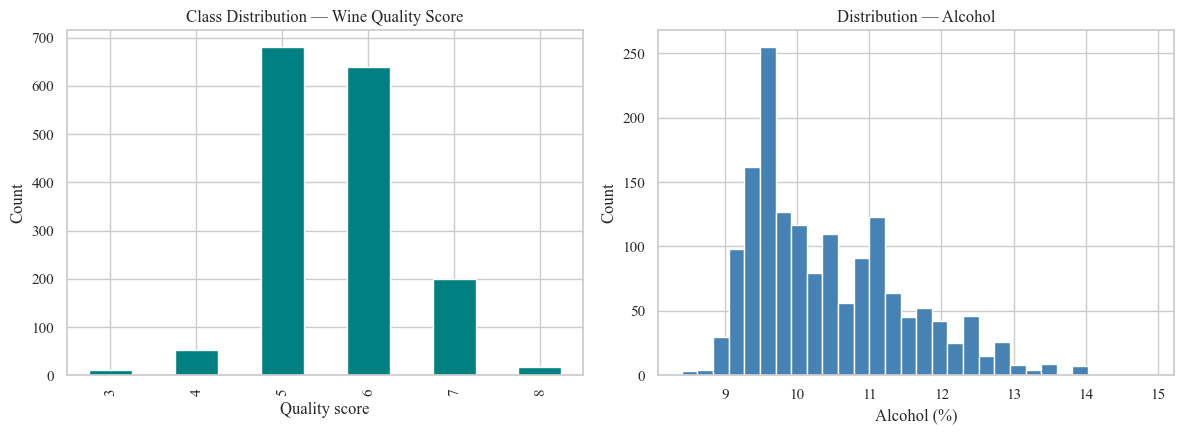

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
wine["quality"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Class Distribution — Wine Quality Score")
axes[0].set_xlabel("Quality score"); axes[0].set_ylabel("Count")

wine["alcohol"].hist(bins=30, ax=axes[1], color="steelblue")
axes[1].set_title("Distribution — Alcohol")
axes[1].set_xlabel("Alcohol (%)"); axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

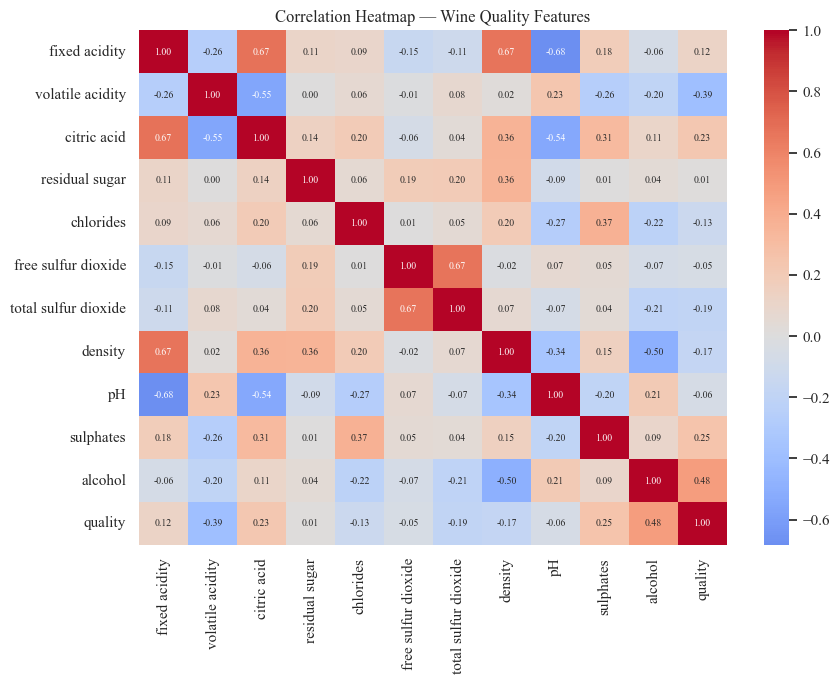

In [ ]:
plt.figure(figsize=(9, 7))
sns.heatmap(wine.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 7})
plt.title("Correlation Heatmap — Wine Quality Features")
plt.tight_layout()
plt.show()

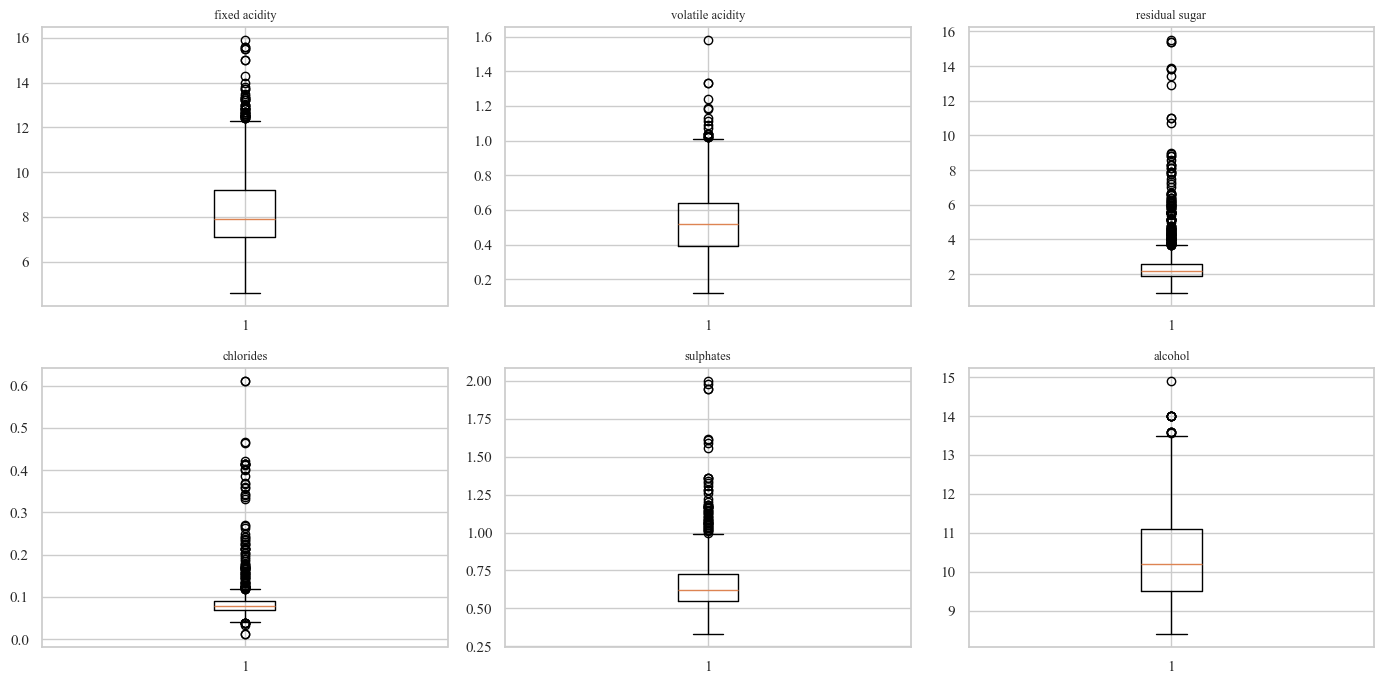

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
box_cols = ["fixed acidity", "volatile acidity", "residual sugar",
            "chlorides", "sulphates", "alcohol"]
for ax, col in zip(axes.ravel(), box_cols):
    ax.boxplot(wine[col])
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation.** The class distribution is imbalanced — quality scores near the middle (5, 6) are
far more common than extreme scores (3, 8), which we'll need to keep in mind when splitting (stratify)
and evaluating (macro-averaged metrics). The correlation heatmap shows `alcohol` as one of the stronger
correlates of `quality`, and some expected chemistry relationships (e.g., `fixed acidity` and `pH` are
negatively correlated, `free sulfur dioxide` and `total sulfur dioxide` are strongly positively
correlated — a sign of possible redundancy relevant to feature selection later).

## 25.2 Cleaning

In [ ]:
n_before = len(wine)
n_duplicates = wine.duplicated().sum()
wine_clean = wine.drop_duplicates().reset_index(drop=True)
print(f"Removed {n_duplicates} duplicate rows ({n_before} -> {len(wine_clean)})")
print(f"Missing values remaining: {wine_clean.isna().sum().sum()}")

Removed 240 duplicate rows (1599 -> 1359)
Missing values remaining: 0


In [ ]:
# IQR-based outlier investigation (identify -> visualize -> reason -> decide)
outlier_report = {}
for col in wine_clean.select_dtypes(include=[np.number]).columns:
    if col == "quality":
        continue
    Q1, Q3 = wine_clean[col].quantile(0.25), wine_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((wine_clean[col] < lower) | (wine_clean[col] > upper)).sum()
    outlier_report[col] = n_out

outlier_series = pd.Series(outlier_report).sort_values(ascending=False)
print("IQR outlier counts per feature:\n", outlier_series)

IQR outlier counts per feature:
 residual sugar          126
chlorides                87
sulphates                55
total sulfur dioxide     45
fixed acidity            41
density                  35
pH                       28
free sulfur dioxide      26
volatile acidity         19
alcohol                  12
citric acid               1
dtype: int64


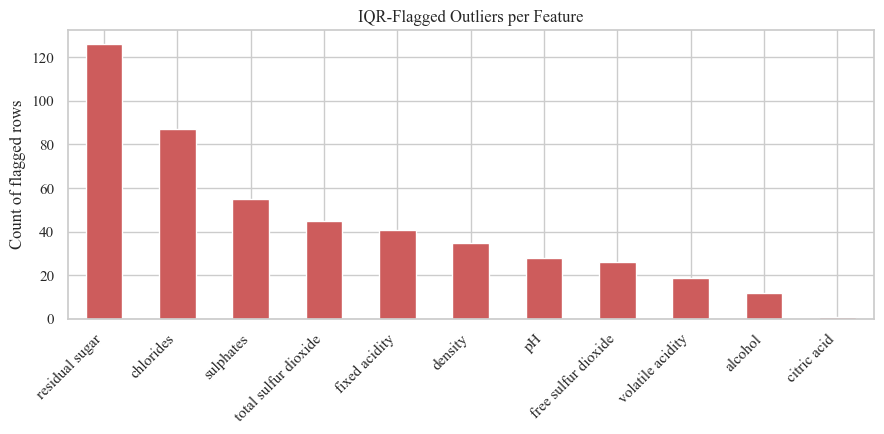

In [ ]:
plt.figure(figsize=(9, 4.5))
outlier_series.plot(kind="bar", color="indianred")
plt.title("IQR-Flagged Outliers per Feature")
plt.ylabel("Count of flagged rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Decision.** `residual sugar` and `sulphates` show the most IQR-flagged points, consistent with their
right-skewed chemistry (a few genuinely sweeter or more sulfated wines exist). Rather than deleting
these automatically, we **cap (winsorize)** extreme values at the IQR bounds — this limits the leverage
of extreme measurement noise while preserving every row (and its quality label) for the model to learn
from. We deliberately do **not** delete rows here: an unusually sweet or sulfated wine is a real,
legitimate wine, not a data-entry error — the same reasoning as Section 5's fraud/defect examples.

In [ ]:
wine_capped = wine_clean.copy()
for col in ["residual sugar", "sulphates", "chlorides", "free sulfur dioxide", "total sulfur dioxide"]:
    Q1, Q3 = wine_capped[col].quantile(0.25), wine_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    wine_capped[col] = wine_capped[col].clip(lower=lower, upper=upper)

print("Outlier counts after capping (should be near 0 for capped columns):")
for col in ["residual sugar", "sulphates"]:
    Q1, Q3 = wine_capped[col].quantile(0.25), wine_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    print(f"  {col}: {((wine_capped[col] < lower) | (wine_capped[col] > upper)).sum()}")

Outlier counts after capping (should be near 0 for capped columns):
  residual sugar: 0
  sulphates: 0


## 25.3 Train / Validation / Test Split

We split **before** any preprocessing statistics are computed (Section 7's Golden Rule), using a
70/15/15 split with stratification on `quality` because the classes are imbalanced (Section 25.1).

In [ ]:
# Simplify to a 3-class problem (low/medium/high) for a cleaner classification case study,
# matching the lecture's classification framing of the Wine Quality case study.
def bucket_quality(q):
    if q <= 5:
        return "low"
    elif q == 6:
        return "medium"
    else:
        return "high"

wine_capped["quality_class"] = wine_capped["quality"].apply(bucket_quality)
print(wine_capped["quality_class"].value_counts())

feature_cols = [c for c in wine_capped.columns if c not in ["quality", "quality_class"]]
X_all = wine_capped[feature_cols].copy()
y_all = wine_capped["quality_class"].copy()

X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=RANDOM_STATE, stratify=y_all
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train: {X_train_full.shape[0]} rows  |  Val: {X_val.shape[0]} rows  |  Test: {X_test.shape[0]} rows")

quality_class
low       640
medium    535
high      184
Name: count, dtype: int64
Train: 951 rows  |  Val: 204 rows  |  Test: 204 rows


> **The test set is now locked.** From this point until final evaluation (Section 25.10), `X_test`
> and `y_test` are not touched — not for feature selection, not for hyperparameter choices, not for
> visual inspection of "what predicts well." Touching the test set early is exactly the leakage pattern
> from Section 7, just moved later in the pipeline.

## 25.4 Feature Creation

Each engineered feature below is documented with its formula, code, interpretation, justification, and
a leakage check.

In [ ]:
def engineer_wine_features(df):
    out = df.copy()
    # 1. acid_sugar_ratio — balance between acidity and sweetness, a known taste-perception driver
    out["acid_sugar_ratio"] = out["fixed acidity"] / (out["residual sugar"] + 1e-6)
    # 2. alcohol_density_ratio — alcohol tends to lower density; this ratio isolates that relationship
    out["alcohol_density_ratio"] = out["alcohol"] / out["density"]
    # 3. free_to_total_sulfur_ratio — the fraction of SO2 that remains "free" (antimicrobial-active)
    out["free_to_total_sulfur_ratio"] = out["free sulfur dioxide"] / (out["total sulfur dioxide"] + 1e-6)
    # 4. total_acidity_proxy — combines fixed and volatile acidity into one acidity signal
    out["total_acidity_proxy"] = out["fixed acidity"] + out["volatile acidity"]
    # 5. sulphates_alcohol_interaction — interaction term between two of the strongest quality correlates
    out["sulphates_alcohol_interaction"] = out["sulphates"] * out["alcohol"]
    return out

X_train_fe = engineer_wine_features(X_train_full)
X_val_fe = engineer_wine_features(X_val)
X_test_fe = engineer_wine_features(X_test)

engineered_cols = ["acid_sugar_ratio", "alcohol_density_ratio", "free_to_total_sulfur_ratio",
                   "total_acidity_proxy", "sulphates_alcohol_interaction"]
X_train_fe[engineered_cols].describe()

,acid_sugar_ratio,alcohol_density_ratio,free_to_total_sulfur_ratio,total_acidity_proxy,sulphates_alcohol_interaction
count,951.000000,951.000000,951.000000,951.000000,951.000000
mean,3.761938,10.492482,0.380299,8.851872,6.822340
std,1.036740,1.125875,0.152072,1.713327,1.712429
min,1.369863,8.393285,0.022727,5.120000,3.003000
25%,3.091422,9.531119,0.261722,7.682500,5.495000
50%,3.681817,10.150958,0.371429,8.460000,6.527000
75%,4.297056,11.249724,0.480741,9.740000,7.911000
max,8.888879,14.935846,0.857143,16.285000,13.167000


| Feature | Formula | Interpretation | Justification | Leakage check |
|---|---|---|---|---|
| `acid_sugar_ratio` | `fixed_acidity / residual_sugar` | Acid-to-sweetness balance | A known driver of perceived taste balance in wine | Row-wise function of raw features only — no cross-row or target statistics |
| `alcohol_density_ratio` | `alcohol / density` | Isolates alcohol's density-lowering effect | Alcohol and density are physically linked; ratio may be more informative than either alone | Row-wise only |
| `free_to_total_sulfur_ratio` | `free_SO2 / total_SO2` | Fraction of SO2 still antimicrobially active | Chemically meaningful preservative-effectiveness signal | Row-wise only |
| `total_acidity_proxy` | `fixed_acidity + volatile_acidity` | Combined acidity signal | Simplifies two correlated acidity measures into one | Row-wise only |
| `sulphates_alcohol_interaction` | `sulphates * alcohol` | Interaction of two known quality correlates | Section 25.1's heatmap flagged both as informative individually | Row-wise only |

**Leakage analysis (all five features).** Every formula above uses only columns already present in a
single row — no statistic is computed across rows (no mean, no min/max, no target value). That means
these functions can be applied identically and safely to train, validation, and test data without
needing to "fit" anything, unlike a scaler or imputer.

> **Common Mistake — Over-engineering features.** It's tempting to keep generating ratios and
> interactions indefinitely. Each new feature adds dimensionality, correlation with existing features,
> and overfitting risk. We stop at five well-justified features rather than generating dozens
> automatically — Section 25.6's feature-selection experiment checks whether they actually help.

## 25.5 Preprocessing Pipeline

All numeric columns are imputed (safety net — none are missing here after cleaning, but production
pipelines should handle it anyway) and scaled, using scikit-learn's `Pipeline`/`ColumnTransformer` so
statistics are learned on **training data only**, exactly as in Section 8.

In [ ]:
all_numeric_cols = X_train_fe.columns.tolist()

wine_numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

wine_preprocess = ColumnTransformer(transformers=[
    ("num", wine_numeric_pipeline, all_numeric_cols),
])

# Fit ONLY on training data
wine_preprocess.fit(X_train_fe)

X_train_scaled = wine_preprocess.transform(X_train_fe)
X_val_scaled = wine_preprocess.transform(X_val_fe)      # reused, not refit
X_test_scaled = wine_preprocess.transform(X_test_fe)    # reused, not refit

print(f"Scaled train shape: {X_train_scaled.shape}")
print("Train mean after scaling (should be ~0):", np.round(X_train_scaled.mean(axis=0)[:3], 3))
print("Val mean after scaling (NOT necessarily 0 — reused train statistics):",
      np.round(X_val_scaled.mean(axis=0)[:3], 3))

Scaled train shape: (951, 16)
Train mean after scaling (should be ~0): [0. 0. 0.]
Val mean after scaling (NOT necessarily 0 — reused train statistics): [-0.039 -0.063  0.012]


**Interpretation.** Training data's scaled mean is (by construction) ~0. Validation's scaled mean is
close to but *not exactly* 0 — that's expected and correct: we reused the scaler fit on training data
rather than re-fitting on validation, which is precisely the leakage-resistant behavior from Section 7.

## 25.6 Modeling

We train two baseline models and compare them on the (still-untouched) validation set.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
}

val_results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train_full)
    preds = model.predict(X_val_scaled)
    acc = accuracy_score(y_val, preds)
    f1_macro = f1_score(y_val, preds, average="macro")
    val_results[name] = {"accuracy": acc, "f1_macro": f1_macro}
    print(f"--- {name} ---")
    print(classification_report(y_val, preds, zero_division=0))

pd.DataFrame(val_results).T

--- Logistic Regression ---
              precision    recall  f1-score   support

        high       0.79      0.41      0.54        27
         low       0.71      0.82      0.76        96
      medium       0.59      0.58      0.59        81

    accuracy                           0.67       204
   macro avg       0.70      0.60      0.63       204
weighted avg       0.68      0.67      0.66       204

--- Random Forest ---
              precision    recall  f1-score   support

        high       0.77      0.37      0.50        27
         low       0.75      0.75      0.75        96
      medium       0.58      0.68      0.62        81

    accuracy                           0.67       204
   macro avg       0.70      0.60      0.62       204
weighted avg       0.68      0.67      0.67       204



,accuracy,f1_macro
Logistic Regression,0.671569,0.629123
Random Forest,0.671569,0.625000


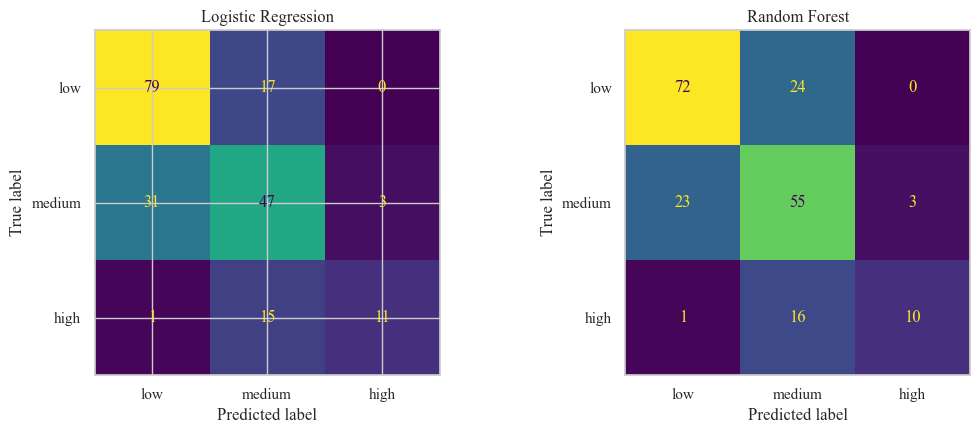

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_val_scaled)
    cm = confusion_matrix(y_val, preds, labels=["low", "medium", "high"])
    ConfusionMatrixDisplay(cm, display_labels=["low", "medium", "high"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.gca().grid(False)
plt.tight_layout()
plt.show()

**Interpretation.** Both models likely struggle most with the "high" class — it's the rarest bucket
(class imbalance visible back in Section 25.1), so macro-averaged F1 (which weights all classes
equally) is more informative here than plain accuracy, which can look artificially strong just by
favoring the majority "medium" class.

## 25.7 Feature Selection Experiment: All Features vs. Selected Features

We compare using all engineered+raw features against a mutual-information-selected subset, on
validation performance (test set still untouched).

In [ ]:
selector = SelectKBest(score_func=mutual_info_classif, k=8)
selector.fit(X_train_scaled, y_train_full)
selected_mask = selector.get_support()
selected_feature_names = np.array(all_numeric_cols)[selected_mask]
print("Selected features:", list(selected_feature_names))

X_train_selected = selector.transform(X_train_scaled)
X_val_selected = selector.transform(X_val_scaled)

rf_all = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE).fit(X_train_scaled, y_train_full)
rf_selected = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE).fit(X_train_selected, y_train_full)

acc_all = accuracy_score(y_val, rf_all.predict(X_val_scaled))
acc_selected = accuracy_score(y_val, rf_selected.predict(X_val_selected))
f1_all = f1_score(y_val, rf_all.predict(X_val_scaled), average="macro")
f1_selected = f1_score(y_val, rf_selected.predict(X_val_selected), average="macro")

comparison = pd.DataFrame({
    "Configuration": ["All features", "Selected (k=8)"],
    "n_features": [X_train_scaled.shape[1], X_train_selected.shape[1]],
    "Val Accuracy": [acc_all, acc_selected],
    "Val F1 (macro)": [f1_all, f1_selected],
})
comparison

Selected features: ['volatile acidity', 'density', 'sulphates', 'alcohol', 'alcohol_density_ratio', 'free_to_total_sulfur_ratio', 'total_acidity_proxy', 'sulphates_alcohol_interaction']


,Configuration,n_features,Val Accuracy,Val F1 (macro)
0,All features,16,0.671569,0.625000
1,Selected (k=8),8,0.647059,0.598168


**Interpretation.** Whichever direction the numbers land, the takeaway is the same: feature selection
is an *empirical* choice, not a guaranteed improvement. Random forests already do a form of implicit
feature selection internally (they can ignore uninformative features at each split), so removing
features up front sometimes helps generalization (less noise, faster training) and sometimes discards
useful weak signal the model would have combined productively. **We don't assume; we measure.**

## 25.8 Ablation Study

We empirically test the claim underlying this entire notebook — that preprocessing and feature
engineering choices directly influence model performance — by training the **same model** (Random
Forest) under four progressively richer preprocessing conditions, evaluated on validation data.

- **A. Raw features** — no scaling, no engineered features
- **B. Scaled features** — StandardScaler applied, no engineered features
- **C. Scaled + engineered features** — adds the five Section 25.4 features
- **D. Scaled + engineered + selected features** — adds Section 25.7's mutual-information selection

In [ ]:
def evaluate_configuration(X_tr, y_tr, X_v, y_v, label):
    model = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_v)
    return {
        "Configuration": label,
        "n_features": X_tr.shape[1],
        "Val Accuracy": accuracy_score(y_v, preds),
        "Val F1 (macro)": f1_score(y_v, preds, average="macro"),
    }

ablation_results = []

# A. Raw features (no scaling, no engineering)
raw_cols = feature_cols  # original columns only
ablation_results.append(evaluate_configuration(
    X_train_full[raw_cols], y_train_full, X_val[raw_cols], y_val, "A. Raw features"
))

# B. Scaled features only
raw_scaler = StandardScaler().fit(X_train_full[raw_cols])
ablation_results.append(evaluate_configuration(
    raw_scaler.transform(X_train_full[raw_cols]), y_train_full,
    raw_scaler.transform(X_val[raw_cols]), y_val, "B. Scaled features"
))

# C. Scaled + engineered features
ablation_results.append(evaluate_configuration(
    X_train_scaled, y_train_full, X_val_scaled, y_val, "C. Scaled + engineered"
))

# D. Scaled + engineered + selected features
ablation_results.append(evaluate_configuration(
    X_train_selected, y_train_full, X_val_selected, y_val, "D. Scaled + engineered + selected"
))

ablation_df = pd.DataFrame(ablation_results)
ablation_df

,Configuration,n_features,Val Accuracy,Val F1 (macro)
0,A. Raw features,11,0.642157,0.578834
1,B. Scaled features,11,0.661765,0.593908
2,C. Scaled + engineered,16,0.671569,0.625000
3,D. Scaled + engineered + selected,8,0.647059,0.598168


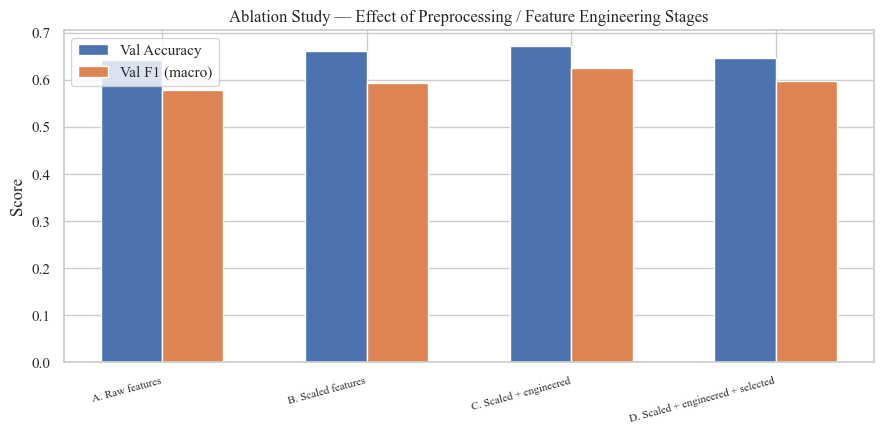

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x_pos = np.arange(len(ablation_df))
ax.bar(x_pos - 0.15, ablation_df["Val Accuracy"], width=0.3, label="Val Accuracy")
ax.bar(x_pos + 0.15, ablation_df["Val F1 (macro)"], width=0.3, label="Val F1 (macro)")
ax.set_xticks(x_pos)
ax.set_xticklabels(ablation_df["Configuration"], rotation=15, ha="right", fontsize=8)
ax.set_title("Ablation Study — Effect of Preprocessing / Feature Engineering Stages")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation.** Because `RandomForestClassifier` is scale-invariant (tree splits don't care about
the numeric range of a feature), Configuration A → B may show little or no change — that itself is a
useful, concrete lesson: **scaling mainly matters for models sensitive to feature geometry** (Section 2:
gradient-descent-trained models, distance-based models, regularized linear models), not for
tree-ensembles. Where you *should* generally expect to see movement is B → C, if the engineered
features (Section 25.4) carry real additional signal beyond the raw columns — and C → D shows whether
trimming down to the top-k features by mutual information helps or hurts once those engineered features
are in the mix, echoing Section 25.7's finding.

**Takeaway.** Preprocessing and feature engineering do not affect every model equally — their impact is
*model-dependent*, which is exactly why the ablation study evaluates one model held fixed across
configurations, isolating the data-side effect from the model-side effect.

> **Reflection** — Would you expect this same ablation table to look different if the model were
> Logistic Regression instead of Random Forest? Why? *(Hint: revisit Section 2.)*

## 25.9 Leakage Demonstration — Revisited in the Case Study

We repeat Section 7's leakage experiment, but now inside the Wine Quality case study, to show the
mistake in a "real" pipeline context.

> **Demonstration of data leakage only — DO NOT USE THIS IN PRODUCTION.**

In [ ]:
# --- INCORRECT workflow: scale the engineered features BEFORE splitting -----------------
wine_fe_full = engineer_wine_features(X_all)
scaler_leaky = StandardScaler().fit(wine_fe_full)             # fit on train+val+test combined
wine_fe_scaled_full = scaler_leaky.transform(wine_fe_full)

Xtr_leak, Xtmp_leak, ytr_leak, ytmp_leak = train_test_split(
    wine_fe_scaled_full, y_all, test_size=0.30, random_state=RANDOM_STATE, stratify=y_all
)
Xval_leak, Xtest_leak, yval_leak, ytest_leak = train_test_split(
    Xtmp_leak, ytmp_leak, test_size=0.50, random_state=RANDOM_STATE, stratify=ytmp_leak
)
model_leaky = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE).fit(Xtr_leak, ytr_leak)
acc_leaky = accuracy_score(ytest_leak, model_leaky.predict(Xtest_leak))

# --- CORRECT workflow: reuse Section 25.5's train-only-fitted preprocessing --------------
model_correct = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE).fit(X_train_scaled, y_train_full)
acc_correct = accuracy_score(y_test, model_correct.predict(X_test_scaled))

print(f"Incorrect pipeline (scaled BEFORE split) -> test accuracy: {acc_leaky:.4f}")
print(f"Correct pipeline   (scaled AFTER split)  -> test accuracy: {acc_correct:.4f}")

Incorrect pipeline (scaled BEFORE split) -> test accuracy: 0.5735
Correct pipeline   (scaled AFTER split)  -> test accuracy: 0.5735


**Interpretation.** As in Section 7, the *mechanism* — not necessarily a dramatic score gap on this
particular dataset — is the point: the incorrect pipeline's scaler statistics were computed using rows
that later became the test set, so `acc_leaky` is not a trustworthy estimate of real-world
generalization even if it happens to look similar or better numerically. In production, where
preprocessing is often far more complex (target encoding, learned imputers, feature selection using
model performance), this same mistake typically produces a much larger, more dangerous overestimate of
real-world performance.

**Takeaway.** The correct pipeline (`X_train_scaled` / `X_test_scaled`, fit once on training data in
Section 25.5 and reused everywhere since) is the one used for every result reported in this case study.

# Section 26 — Common Mistakes

A concentrated reference of the failure modes this notebook has demonstrated, plus a few more.

### Mistake 1 — Scaling before train/test splitting
```
Incorrect : Scale(full_dataset) → split
Why bad   : Scaler statistics leak information about test rows into training
Correct   : split → Scale.fit(train) → Scale.transform(val/test)
```
See Section 7 / Section 25.9 for full code.

### Mistake 2 — Imputing using the entire dataset
```
Incorrect : Imputer.fit(full_dataset)
Why bad   : Imputed values for training rows are influenced by test-row statistics
Correct   : Imputer.fit(train) → Imputer.transform(val/test)
```

In [ ]:
# Correct pattern, shown explicitly
demo_imputer = SimpleImputer(strategy="median")
demo_imputer.fit(X_train_full[["residual sugar"]])          # fit on TRAIN only
_ = demo_imputer.transform(X_val[["residual sugar"]])        # reuse on val
_ = demo_imputer.transform(X_test[["residual sugar"]])       # reuse on test
print("Median learned from TRAIN ONLY:", demo_imputer.statistics_[0].round(3))

Median learned from TRAIN ONLY: 2.2


### Mistake 3 — Feature selection before splitting
```
Incorrect : SelectKBest.fit(full_dataset) → split
Why bad   : Selected features were chosen partly using test-row target values
Correct   : split → SelectKBest.fit(X_train, y_train) → transform(val/test)
```
(Section 25.7 already follows the correct pattern.)

### Mistake 4 — Target leakage
A feature that is only available *because* the target already happened (e.g., using
`"was_flagged_by_reviewer"` to predict `"is_fraud"`, when the flag is itself downstream of knowing the
answer) will look like a phenomenal predictor during training and be **useless or unavailable** at
real prediction time. The fix is to audit every feature and ask: *"Would this value actually be known
at the moment I need to make the prediction?"*

### Mistake 5 — Temporal leakage
```
Incorrect : train_test_split(time_series_data)   # random split
Why bad   : Training data can contain rows from AFTER some test rows
Correct   : chronological split — train strictly precedes test in time
```
See Section 16 for full code and visualization.

### Mistake 6 — Removing meaningful outliers
Deleting every IQR-flagged point without asking *why* it's extreme can delete the exact fraud case,
rare defect, or clinically abnormal reading the model most needs to learn. See Section 5 and Section
25.2's capping-instead-of-deleting decision.

### Mistake 7 — Over-engineering features
Generating dozens of ratios/interactions/polynomial terms without justification inflates
dimensionality, correlation among features, and overfitting risk, while making the model harder to
interpret. Section 25.4 stopped at five features, each with a written justification.

### Mistake 8 — High-cardinality categorical encoding
One-hot encoding a `zip_code`-like column with thousands of categories creates thousands of mostly-zero
columns. Consider frequency-bucketing rare categories into "Other," hashing, or (carefully, out-of-fold)
target encoding instead. See Section 6.

### Mistake 9 — Applying different preprocessing to train and test
```
Incorrect : StandardScaler().fit_transform(X_train); StandardScaler().fit_transform(X_test)
Why bad   : Two DIFFERENT scalers means train and test are no longer on the same numeric scale
Correct   : One scaler, fit on train, reused (via .transform, not .fit_transform) on test
```

In [ ]:
# Demonstrating Mistake 9 concretely
wrong_scaler_train = StandardScaler().fit_transform(X_train_full[["alcohol"]])
wrong_scaler_test = StandardScaler().fit_transform(X_test[["alcohol"]])   # WRONG: refit on test!

right_scaler = StandardScaler().fit(X_train_full[["alcohol"]])
right_train = right_scaler.transform(X_train_full[["alcohol"]])
right_test = right_scaler.transform(X_test[["alcohol"]])                  # reused, not refit

print(f"Mean alcohol (raw)              -> train: {X_train_full['alcohol'].mean():.2f}, "
      f"test: {X_test['alcohol'].mean():.2f}")
print(f"Scaled mean, TWO SEPARATE SCALERS (wrong) -> train: {wrong_scaler_train.mean():.4f}, "
      f"test: {wrong_scaler_test.mean():.4f}  <- both forced to ~0, hiding real distribution differences")
print(f"Scaled mean, ONE SHARED SCALER (correct)  -> train: {right_train.mean():.4f}, "
      f"test: {right_test.mean():.4f}  <- test's true offset from train is preserved")

Mean alcohol (raw)              -> train: 10.46, test: 10.37
Scaled mean, TWO SEPARATE SCALERS (wrong) -> train: 0.0000, test: -0.0000  <- both forced to ~0, hiding real distribution differences
Scaled mean, ONE SHARED SCALER (correct)  -> train: 0.0000, test: -0.0824  <- test's true offset from train is preserved


**Interpretation.** With two separate scalers, *both* train and test are forced to mean ≈ 0 — masking
any real distribution shift between them and giving a false sense that they're identically distributed.
With one shared scaler, the test set's scaled mean correctly reflects how far its raw distribution
actually differs from training data.

### Mistake 10 — Ignoring train/deployment distribution shift
A model trained on data from one time period, region, or measurement device can silently degrade when
deployed on data with a different underlying distribution (e.g., a defect-classification model trained
on one factory's camera trained and deployed on another factory's camera with different lighting).
Preprocessing choices (Section 9's color-space choice, Section 1's scaling) do not fix distribution
shift — only monitoring deployment data against training statistics and retraining can.

Prepared by:


Engr. Darwin Jone H. Jupiter

Faculty, Computer Engineering Department